# S&P 500 – Marktbreite als Frühindikator für ein Ampelsystem

### Eine Hypothesenanalyse auf Basis der prozentualen Marktbreite

Diese Analyse untersucht, ob die Marktbreite des S&P 500 – der Anteil der
Indexmitglieder, die über ihrem eigenen gleitenden Durchschnitt (SMA20/50/200)
notieren – eigenständige Aussagekraft für die Rendite- und Risikoentwicklung
des Gesamtindex besitzt. Die Marktbreite misst, wie viele einzelne
Indexmitglieder eine Trendbewegung tatsächlich mittragen – eine breit
getragene Rally gilt als robuster als eine von wenigen Werten getriebene.
Ziel ist die Identifikation robuster, statistisch abgesicherter
Frühindikatoren als Bausteine für ein indikatorbasiertes Ampelsystem, das
die aktuelle Marktphase hinsichtlich ihres Rendite- und Risikoprofils
einordnet.

Neun Hypothesen werden untersucht (B1–B9), gefolgt von einer breitenbasierten
Ampel-Systematik und einer Was-wäre-wenn-Analyse:

**Aufbau:**

1. Datenbezug und Aufbereitung
2. Datenbereinigung und Plausibilisierung
3. Methodik und Hypothesenübersicht
4. Hypothesenanalyse (B1–B9)
5. Einordnung und Handlungsempfehlungen
6. Ampel-Systematik auf Basis der Marktbreite
7. Was-wäre-wenn-Analyse
8. Export der Ergebnisse
9. Zusammenfassung


## 1. Datenbezug und Aufbereitung


### 1.1 Verwendete Bibliotheken


In [1]:
# Numerik, Tabellenverarbeitung und Pfadhandling
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import combinations

# Statistische Tests (Welch-t-Test, Mann-Whitney-U, Kruskal-Wallis) für die
# Gruppen- bzw. Quartilsvergleiche in Abschnitt 3
from scipy import stats
import matplotlib.pyplot as plt

# Einheitliche Farbpalette für sämtliche Diagramme des Notebooks
COLOR_PRICE = "#0b0b0b"
COLOR_A     = "#2a78d6"
COLOR_B     = "#eb6834"
COLOR_GOOD  = "#0ca30c"
COLOR_WARN  = "#e0a72c"
COLOR_BAD   = "#d03b3b"
COLOR_GRID  = "#e1e0d9"
COLOR_MUTED = "#898781"
# Vier sequenzielle Farben für die Quartils-Diagramme (B3, dunkler = höhere Breite)
COLOR_QUARTILE = ["#f2c6b4", "#eb6834", "#2a78d6", "#123a63"]

plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "axes.grid": True,
    "grid.color": COLOR_GRID,
    "grid.linewidth": 0.8,
    "axes.edgecolor": COLOR_MUTED,
    "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED,
    "font.size": 10,
})

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("Bibliotheken geladen.")


Bibliotheken geladen.


### 1.2 Konfiguration


In [2]:
# Zu untersuchender Index
INDEX_NAME = "S&P 500"

# Fensterlängen der Marktbreite-Kennzahl (Anteil Mitglieder über eigenem SMA)
BREADTH_WINDOWS = [20, 50, 200]

# Rohdaten-Dateien je Fenster (TradingView-Export: Anteil S&P-500-Mitglieder
# über ihrem eigenen SMA20/50/200, täglicher Schlusswert in Prozent)
BREADTH_FILES = {
    20:  Path("Rohdaten/S&P500 20 SMA 20061229 - 20260804.csv"),
    50:  Path("Rohdaten/S&P 500 50 SMA 20061229 - 20260804.csv"),
    200: Path("Rohdaten/S&P 500 200 SMA 19901015 - 20260804.csv"),
}

# Kursdaten inkl. bereits berechneter Wochenbasis-SMA und Vorwärts-Zielgrößen
# (fwd_return/fwd_mdd) für die Horizonte 30/60/90 Handelstage.
PRICE_FILE = Path("../data/S&P_500_clean_with_sma.csv")

# Analysezeitraum: Die Breitendaten liegen ab 2006-12-29 täglich vor (die
# Datei zum SMA200-Fenster enthält zusätzlich einen für die Analyse
# ungeeigneten, nur alle ~57 Tage befüllten Vorlauf bis 1990 - siehe Abschnitt
# 2.1). Der Analysezeitraum wird daher einheitlich auf den ersten
# vollständigen, täglich vorliegenden Handelstag begrenzt.
START_DATE_ANALYSE = "2007-01-01"

# Feste (absolute) Quartilsgrenzen der Marktbreite in Prozent - konsistent mit
# den in B4/B5/B6/B7 verwendeten Schwellen von 25/50/75 %.
QUARTIL_GRENZEN = [0, 25, 50, 75, 100]
QUARTIL_LABELS = ["Q1 (0-25%)", "Q2 (25-50%)", "Q3 (50-75%)", "Q4 (75-100%)"]

# Prognosehorizonte in Handelstagen (identisch zu den bereits vorliegenden
# fwd_return_*/fwd_mdd_*-Spalten der Kursdaten)
HORIZONS = [30, 60, 90]

# Zielordner für den Export der Ergebnistabellen (Abschnitt 8)
EXPORT_DIR = Path("Hypothesenanalysen")
EXPORT_DIR.mkdir(exist_ok=True)

print(f"Untersuchter Index: {INDEX_NAME}")
print(f"Marktbreite-Fenster: {BREADTH_WINDOWS}")
print(f"Analysezeitraum ab: {START_DATE_ANALYSE}")
print(f"Ergebnisordner: {EXPORT_DIR.resolve()}")


Untersuchter Index: S&P 500
Marktbreite-Fenster: [20, 50, 200]
Analysezeitraum ab: 2007-01-01
Ergebnisordner: C:\Users\ramos\OneDrive\Privat\Data Science Institute\Abschlussprojekt - final\Breitenindikatoren\Hypothesenanalysen


### 1.3 Marktbreite-Datenbezug


In [3]:
def lade_breite(pfad: Path, fenster: int) -> pd.Series:
    '''Lädt eine TradingView-Marktbreite-Exportdatei und liefert den
    täglichen Schlusswert (Anteil Mitglieder über eigenem SMA, in Prozent)
    als benannte Series. Die Spalten open/high/low sowie die vier unbenannten
    EMA-Glättungsspalten werden nicht verwendet (siehe Abschnitt 2.1).'''
    rohdaten = pd.read_csv(pfad, parse_dates=["time"])
    reihe = rohdaten.set_index("time")["close"]
    reihe.index.name = "Date"
    reihe.name = f"breite_sma{fenster}"
    return reihe


breite_rohdaten = {w: lade_breite(pfad, w) for w, pfad in BREADTH_FILES.items()}
for w, reihe in breite_rohdaten.items():
    print(f"SMA{w}: {len(reihe):,} Zeilen, Zeitraum {reihe.index.min().date()} bis "
          f"{reihe.index.max().date()}, Wertebereich {reihe.min():.2f} bis {reihe.max():.2f}")


SMA20: 4,951 Zeilen, Zeitraum 2006-12-29 bis 2026-08-04, Wertebereich 0.19 bis 99.00
SMA50: 4,951 Zeilen, Zeitraum 2006-12-29 bis 2026-08-04, Wertebereich 0.20 bis 97.42
SMA200: 5,053 Zeilen, Zeitraum 1990-10-15 bis 2026-08-04, Wertebereich 1.62 bis 96.82


### 1.4 Kursdatenbezug


In [4]:
def lade_kursdaten(pfad: Path) -> pd.DataFrame:
    '''Lädt die bereits bereinigten Kurs- und SMA-Daten des Index
    (Date, Close, wöchentliche SMA sowie Vorwärts-Zielgrößen für
    30/60/90 Handelstage).'''
    df = pd.read_csv(pfad, parse_dates=["Date"], index_col="Date")
    return df


preis_df = lade_kursdaten(PRICE_FILE)
print(f"Kursdaten: {len(preis_df):,} Zeilen, Zeitraum {preis_df.index.min().date()} bis "
      f"{preis_df.index.max().date()}")
preis_df[["Close"] + [f"fwd_return_{h}d" for h in HORIZONS]].tail()


Kursdaten: 4,930 Zeilen, Zeitraum 2007-01-03 bis 2026-08-07


,Close,fwd_return_30d,fwd_return_60d,fwd_return_90d
Date,,,,
2026-08-03,"7,600.5000",NaN,NaN,NaN
2026-08-04,"7,736.5200",NaN,NaN,NaN
2026-08-05,"7,723.5498",NaN,NaN,NaN
2026-08-06,"7,709.9600",NaN,NaN,NaN
2026-08-07,"7,757.6401",NaN,NaN,NaN


## 2. Datenbereinigung und Plausibilisierung


### 2.1 Datenqualitätsprüfung


In [5]:
def breite_qualität_report(reihe: pd.Series) -> dict:
    gap_days = reihe.index.to_series().diff().dt.days
    return {
        "Anzahl Zeilen": len(reihe),
        "Duplizierte Datums-Indizes": int(reihe.index.duplicated().sum()),
        "Fehlende Werte": int(reihe.isna().sum()),
        "Werte außerhalb 0-100": int(((reihe < 0) | (reihe > 100)).sum()),
        "Größte Datenlücke (Kalendertage)": float(gap_days.max()) if len(gap_days.dropna()) else np.nan,
        "Anteil Lücken > 30 Kalendertage": float((gap_days > 30).mean()),
    }


print("--- Datenqualitätsbericht je Marktbreite-Fenster (Rohdaten) ---")
for w, reihe in breite_rohdaten.items():
    print(f"\nSMA{w}:")
    for k, v in breite_qualität_report(reihe).items():
        print(f"  {k:.<48s} {v}")


--- Datenqualitätsbericht je Marktbreite-Fenster (Rohdaten) ---

SMA20:
  Anzahl Zeilen................................... 4951
  Duplizierte Datums-Indizes...................... 0
  Fehlende Werte.................................. 0
  Werte außerhalb 0-100........................... 0
  Größte Datenlücke (Kalendertage)................ 5.0
  Anteil Lücken > 30 Kalendertage................. 0.0

SMA50:
  Anzahl Zeilen................................... 4951
  Duplizierte Datums-Indizes...................... 0
  Fehlende Werte.................................. 0
  Werte außerhalb 0-100........................... 0
  Größte Datenlücke (Kalendertage)................ 5.0
  Anteil Lücken > 30 Kalendertage................. 0.0

SMA200:
  Anzahl Zeilen................................... 5053
  Duplizierte Datums-Indizes...................... 0
  Fehlende Werte.................................. 0
  Werte außerhalb 0-100........................... 0
  Größte Datenlücke (Kalendertage)............

**Befund:** Bei SMA200 zeigt sich ein deutlich höherer Anteil großer
Datenlücken als bei SMA20/SMA50 - die Datei ist vor 2007 nur alle rund 57
Tage befüllt (ein Exportartefakt der Datenquelle, vermutlich ein Limit an
darstellbaren Balken bei sehr langen Zeiträumen), danach durchgehend
täglich. Da alle drei Fenster ab 2007 täglich vorliegen und auch die
Kursdaten dort beginnen, wird der Analysezeitraum unten einheitlich auf
`START_DATE_ANALYSE` (2007-01-01) begrenzt; der dünn besetzte Vorlauf bis
1990 wird nicht verwendet.


### 2.2 Bereinigungsschritte


In [6]:
def bereinige_breite(reihe: pd.Series) -> pd.Series:
    bereinigt = reihe[~reihe.index.duplicated(keep="first")].sort_index()
    bereinigt = bereinigt.loc[bereinigt.index >= START_DATE_ANALYSE]
    return bereinigt


breite_bereinigt = {w: bereinige_breite(r) for w, r in breite_rohdaten.items()}

# Zusammenführung der drei Marktbreite-Fenster zu einer gemeinsamen Tabelle
breite_df = pd.concat(breite_bereinigt.values(), axis=1)
print(f"Marktbreite (alle Fenster gemeinsam) nach Bereinigung: {len(breite_df):,} Zeilen "
      f"({breite_df.index.min().date()} bis {breite_df.index.max().date()})")

n_unvollständig = int(breite_df.isna().any(axis=1).sum())
print(f"Handelstage mit mindestens einem fehlenden Breitenwert: {n_unvollständig} "
      f"({n_unvollständig / len(breite_df):.1%})")
breite_df = breite_df.dropna()


Marktbreite (alle Fenster gemeinsam) nach Bereinigung: 4,950 Zeilen (2007-01-02 bis 2026-08-04)
Handelstage mit mindestens einem fehlenden Breitenwert: 0 (0.0%)


### 2.3 Zusammenführung mit den Kursdaten


In [7]:
# Innerer Verbund über den Handelskalender: TradingView (Marktbreite) und
# Yahoo Finance (Kurs) weichen an einzelnen Tagen leicht voneinander ab: Nur
# Handelstage, die in beiden Quellen vorhanden sind, gehen in die Analyse ein.
df = breite_df.join(preis_df, how="inner")
df = df.loc[df.index >= START_DATE_ANALYSE].copy()

anteil_verworfen_breite = 1 - len(df) / len(breite_df)
print(f"Gemeinsamer Datensatz: {len(df):,} Handelstage "
      f"({df.index.min().date()} bis {df.index.max().date()})")
print(f"Davon durch den Kalenderabgleich verworfene Breiten-Handelstage: {anteil_verworfen_breite:.2%}")
df[[f"breite_sma{w}" for w in BREADTH_WINDOWS] + ["Close"]].describe()


Gemeinsamer Datensatz: 4,927 Handelstage (2007-01-03 bis 2026-08-04)
Davon durch den Kalenderabgleich verworfene Breiten-Handelstage: 0.46%


,breite_sma20,breite_sma50,breite_sma200,Close
count,"4,927.0000","4,927.0000","4,927.0000","4,927.0000"
mean,55.3740,57.0669,61.2321,"2,804.0927"
std,22.7120,21.2623,20.9830,"1,669.9496"
min,0.1900,0.2000,1.6200,676.5300
25%,39.8000,43.5100,49.5000,"1,418.4450"
50%,58.8400,60.9400,64.4800,"2,173.6001"
75%,73.3150,73.3500,76.1900,"3,958.6700"
max,99.0000,97.4200,96.8200,"7,736.5200"


### 2.4 Wöchentlicher Indextrend


In [8]:
# Wöchentlicher Trend des Index: positiv, wenn der Kurs über seiner
# wöchentlichen SMA50 (ca. ein Jahr) notiert. Ein deutlich längeres Fenster
# (z. B. 200 Wochen, ca. vier Jahre) hat vor 2010 noch keinen gültigen Wert
# und würde die Finanzkrise 2008/2009 damit komplett aus der Trend-
# klassifikation ausblenden; außerdem läge der Kurs über nahezu den
# gesamten Analysezeitraum praktisch durchgehend darüber, was einen
# negativen Wochentrend fast nie beobachtbar machen würde. Die 50-Wochen-SMA
# liefert dagegen bereits ab 2008 gültige Werte und eine deutlich
# ausgeglichenere Verteilung positiver und negativer Trendphasen, bleibt
# dabei aber träge genug für ein Wochenbasis-Signal.
wochenschluss_trend = preis_df["Close"].resample("W-FRI").last().dropna()
sma50_wochenbasis = wochenschluss_trend.rolling(window=50, min_periods=50).mean().rename("SMA50_w")
mapping_sma50_w = pd.merge_asof(
    df.reset_index()[["Date"]], sma50_wochenbasis.reset_index(), on="Date", direction="backward",
)
df["SMA50_w"] = mapping_sma50_w["SMA50_w"].values

valide_trend = df["SMA50_w"].notna()
df["Wochentrend_positiv"] = np.where(valide_trend, df["Close"] > df["SMA50_w"], np.nan)

verteilung = df["Wochentrend_positiv"].value_counts(dropna=False)
print("Verteilung des wöchentlichen Trends (1.0 = positiv, 0.0 = negativ, NaN = kein SMA50_w):")
print(verteilung)


Verteilung des wöchentlichen Trends (1.0 = positiv, 0.0 = negativ, NaN = kein SMA50_w):
Wochentrend_positiv
1.0000    3612
0.0000    1075
NaN        240
Name: count, dtype: int64


### 2.5 Zielgrößen


In [9]:
# Die Vorwärts-Zielgrößen (Rendite und maximaler Rücklauf über 30/60/90
# Handelstage) sind bereits im Kursdatensatz enthalten und werden unverändert
# übernommen.
zielgrößen_spalten = [f"fwd_return_{h}d" for h in HORIZONS] + [f"fwd_mdd_{h}d" for h in HORIZONS]
df[zielgrößen_spalten].describe()


,fwd_return_30d,fwd_return_60d,fwd_return_90d,fwd_mdd_30d,fwd_mdd_60d,fwd_mdd_90d
count,"4,900.0000","4,870.0000","4,840.0000","4,900.0000","4,870.0000","4,840.0000"
mean,0.0118,0.0237,0.0353,-0.0513,-0.0756,-0.0935
std,0.0561,0.0764,0.0932,0.0461,0.0621,0.0727
min,-0.3276,-0.4129,-0.3958,-0.3392,-0.4215,-0.4236
25%,-0.0126,-0.0090,-0.0074,-0.0636,-0.0943,-0.1028
50%,0.0183,0.0347,0.0477,-0.0390,-0.0569,-0.0720
75%,0.0441,0.0687,0.0902,-0.0219,-0.0388,-0.0477
max,0.2820,0.3916,0.4509,-0.0039,-0.0076,-0.0115


## 3. Methodik und Hypothesenübersicht


### 3.1 Statistisches Prüfverfahren


In [10]:
def vergleiche_gruppen(gruppe_a: pd.Series, gruppe_b: pd.Series,
                        label_a: str = "Gruppe A", label_b: str = "Gruppe B") -> dict | None:
    a = gruppe_a.dropna()
    b = gruppe_b.dropna()

    # Mindeststichprobe je Gruppe, unterhalb derer ein Test nicht als
    # belastbar gilt - Vergleich wird in diesem Fall übersprungen (None).
    if len(a) < 10 or len(b) < 10:
        return None

    # Welch-t-Test (robust bei ungleicher Varianz) und Mann-Whitney-U-Test
    # (verteilungsfrei) parallel geprüft; als "signifikant" gilt nur ein
    # Ergebnis, das in beiden Tests unter 5 % liegt.
    t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(a, b, alternative="two-sided")

    return {
        "label_a": label_a, "n_a": len(a), "mean_a": a.mean(), "median_a": a.median(), "std_a": a.std(),
        "label_b": label_b, "n_b": len(b), "mean_b": b.mean(), "median_b": b.median(), "std_b": b.std(),
        "t_pvalue": t_p, "u_pvalue": u_p,
        "signifikant_5pct": bool(t_p < 0.05 and u_p < 0.05),
    }


def vergleiche_quartile(gruppen: dict[str, pd.Series]) -> dict | None:
    '''Omnibus-Vergleich über alle vier Quartile per Kruskal-Wallis-Test
    (verteilungsfreies Pendant zur einfaktoriellen ANOVA), ergänzt um den
    paarweisen Extremvergleich Q1 vs. Q4 mit vergleiche_gruppen(). Bei
    Mehrfachvergleichen (hier: ein Omnibustest je Fenster/Horizont/
    Zielgröße) ist die Gefahr eines zufälligen Treffers höher als bei
    einem Einzeltest - die Ergebnisse sind daher im Zusammenhang der
    gesamten Tabelle zu interpretieren, nicht isoliert je Zeile.'''
    bereinigt = {k: v.dropna() for k, v in gruppen.items()}
    if any(len(v) < 10 for v in bereinigt.values()):
        return None

    h_stat, h_p = stats.kruskal(*bereinigt.values())
    q1_vs_q4 = vergleiche_gruppen(bereinigt[QUARTIL_LABELS[0]], bereinigt[QUARTIL_LABELS[3]],
                                   QUARTIL_LABELS[0], QUARTIL_LABELS[3])

    ergebnis = {
        "kw_pvalue": h_p,
        "kw_signifikant_5pct": bool(h_p < 0.05),
    }
    for label in QUARTIL_LABELS:
        ergebnis[f"mean_{label}"] = bereinigt[label].mean()
        ergebnis[f"n_{label}"] = len(bereinigt[label])
    if q1_vs_q4:
        ergebnis["q1_vs_q4_t_pvalue"] = q1_vs_q4["t_pvalue"]
        ergebnis["q1_vs_q4_u_pvalue"] = q1_vs_q4["u_pvalue"]
        ergebnis["q1_vs_q4_signifikant_5pct"] = q1_vs_q4["signifikant_5pct"]
    return ergebnis


def ergebnisse_zu_tabelle(ergebnisse: list[dict]) -> pd.DataFrame:
    return pd.DataFrame(ergebnisse)


alle_ergebnisse: dict[str, pd.DataFrame] = {}
print("Statistisches Prüfverfahren definiert.")


Statistisches Prüfverfahren definiert.


### 3.2 Grafische Auswertung


In [11]:
def plotte_gruppenvergleich(tabelle: pd.DataFrame, titel: str) -> None:
    fig, achsen = plt.subplots(1, 2, figsize=(11, 4))
    for achse, ziel, beschriftung in zip(achsen, ["fwd_return", "fwd_mdd"],
                                          ["Ø Vorwärtsrendite", "Ø maximaler Rücklauf (Drawdown)"]):
        teil = tabelle[tabelle["zielgröße"] == ziel]
        x = np.arange(len(teil))
        breite = 0.35
        achse.bar(x - breite / 2, teil["mean_a"] * 100, breite, label=teil["label_a"].iloc[0], color=COLOR_A)
        achse.bar(x + breite / 2, teil["mean_b"] * 100, breite, label=teil["label_b"].iloc[0], color=COLOR_B)
        achse.set_xticks(x)
        achse.set_xticklabels([f"{h}d" for h in teil["horizont_tage"]])
        achse.set_ylabel(f"{beschriftung} (%)")
        achse.axhline(0, color=COLOR_MUTED, linewidth=0.8)
        achse.legend(fontsize=8)
    fig.suptitle(titel)
    fig.tight_layout()
    plt.show()


def plotte_quartile(tabelle_quartile: pd.DataFrame, horizont: int, titel: str) -> None:
    '''Balkendiagramm der mittleren Vorwärtsrendite bzw. des mittleren
    Drawdowns je Quartil, für einen festen Horizont.'''
    fig, achsen = plt.subplots(1, 2, figsize=(11, 4))
    for achse, ziel_prefix, beschriftung in zip(
        achsen, ["fwd_return", "fwd_mdd"], ["Ø Vorwärtsrendite", "Ø maximaler Rücklauf (Drawdown)"]
    ):
        zeile = tabelle_quartile[(tabelle_quartile["horizont_tage"] == horizont) &
                                  (tabelle_quartile["zielgröße"] == ziel_prefix)].iloc[0]
        werte = [zeile.get(f"mean_{label}") for label in QUARTIL_LABELS]
        achse.bar(QUARTIL_LABELS, [w * 100 if w is not None else np.nan for w in werte], color=COLOR_QUARTILE)
        achse.set_ylabel(f"{beschriftung} {horizont}d (%)")
        achse.axhline(0, color=COLOR_MUTED, linewidth=0.8)
        plt.setp(achse.get_xticklabels(), rotation=15, ha="right")
    fig.suptitle(titel)
    fig.tight_layout()
    plt.show()


print("Funktionen zur grafischen Auswertung definiert.")


Funktionen zur grafischen Auswertung definiert.


### 3.3 Untersuchte Hypothesen

| # | Hypothese | Typ |
|---|---|---|
| B1 | Marktbreite-Regime: Breite > 50 % vs. < 50 %, je SMA-Fenster | Zustand (großzahlig) |
| B2 | Richtung der Marktbreite: steigend vs. fallend, je SMA-Fenster | Zustand (großzahlig) |
| B3 | Marktbreite in festen Quartilen (0-25/25-50/50-75/75-100 %), je SMA-Fenster | Zustand (großzahlig) |
| B4 | Frühindikator Krise: SMA200-Breite > 75 %, danach fällt SMA20-Breite vor SMA200-Breite unter 50 % | Ereignis (selten) |
| B5 | Frühindikator Erholung: Spiegelbild von B4 | Ereignis (selten) |
| B6 | Wochentrend positiv + Breite verlässt oberes Quartil bzw. fällt unter 50 %, je Fenster | Ereignis |
| B7 | Wochentrend negativ + Breite verlässt unteres Quartil bzw. steigt über 50 %, je Fenster | Ereignis |
| B8 | Divergenz: Kurshoch ohne Breitenbestätigung, je Fenster | Ereignis |
| B9 | Breadth Thrust/Collapse: schneller Breitenwechsel binnen 10 Handelstagen, je Fenster | Ereignis (selten) |

B1-B3 sind Zustandsgrößen mit tausenden Beobachtungstagen je Gruppe und
liefern damit die statistisch robusteste Grundlage. B4-B9 sind demgegenüber
Ereignishypothesen mit potenziell sehr wenigen historischen Vorkommen -
Ergebnisse mit weniger als 10 Ereignissen werden je Gruppe rein deskriptiv (Tabelle
der Einzelereignisse) statt mit Signifikanztest ausgewiesen.


## 4. Hypothesenanalyse


### 4.1 B1 - Marktbreite-Regime (> 50 % vs. < 50 %)

**Hypothese:** Notiert die Mehrheit der Indexmitglieder über ihrem eigenen
SMA (Breite > 50 %), unterscheidet sich die Folgeperiode des Gesamtindex von
Tagen, an denen die Minderheit darüber notiert (Breite < 50 %). 


In [12]:
def breite_regime(fenster: int) -> tuple[pd.Series, pd.Series]:
    breite = df[f"breite_sma{fenster}"]
    über = breite > 50
    unter = breite <= 50
    return über, unter


ergebnisse_b1 = []
for w in BREADTH_WINDOWS:
    über, unter = breite_regime(w)
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[über, f"{ziel}_{h}d"], df.loc[unter, f"{ziel}_{h}d"],
                label_a=f"Breite SMA{w} > 50%", label_b=f"Breite SMA{w} < 50%",
            )
            if res:
                res.update({"sma_fenster": w, "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_b1.append(res)

tabelle_b1 = ergebnisse_zu_tabelle(ergebnisse_b1)
alle_ergebnisse["B1_Breite_Regime"] = tabelle_b1
spalten_anzeige = ["sma_fenster", "horizont_tage", "zielgröße", "label_a", "mean_a", "label_b", "mean_b",
                    "t_pvalue", "u_pvalue", "signifikant_5pct"]
spalten_anzeige_einfach = [c for c in spalten_anzeige if c != "sma_fenster"]
tabelle_b1[spalten_anzeige]


,sma_fenster,horizont_tage,zielgröße,label_a,mean_a,label_b,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,30,fwd_return,Breite SMA20 > 50%,0.0081,Breite SMA20 < 50%,0.0183,0.0000,0.0000,True
1,20,30,fwd_mdd,Breite SMA20 > 50%,-0.0463,Breite SMA20 < 50%,-0.0598,0.0000,0.0000,True
2,20,60,fwd_return,Breite SMA20 > 50%,0.0196,Breite SMA20 < 50%,0.0307,0.0000,0.0000,True
3,20,60,fwd_mdd,Breite SMA20 > 50%,-0.0703,Breite SMA20 < 50%,-0.0846,0.0000,0.0000,True
4,20,90,fwd_return,Breite SMA20 > 50%,0.0313,Breite SMA20 < 50%,0.0419,0.0004,0.0000,True
5,20,90,fwd_mdd,Breite SMA20 > 50%,-0.0882,Breite SMA20 < 50%,-0.1025,0.0000,0.0000,True
6,50,30,fwd_return,Breite SMA50 > 50%,0.0075,Breite SMA50 < 50%,0.0204,0.0000,0.0000,True
7,50,30,fwd_mdd,Breite SMA50 > 50%,-0.0452,Breite SMA50 < 50%,-0.0633,0.0000,0.0000,True
8,50,60,fwd_return,Breite SMA50 > 50%,0.0196,Breite SMA50 < 50%,0.0318,0.0000,0.0000,True
9,50,60,fwd_mdd,Breite SMA50 > 50%,-0.0687,Breite SMA50 < 50%,-0.0895,0.0000,0.0000,True


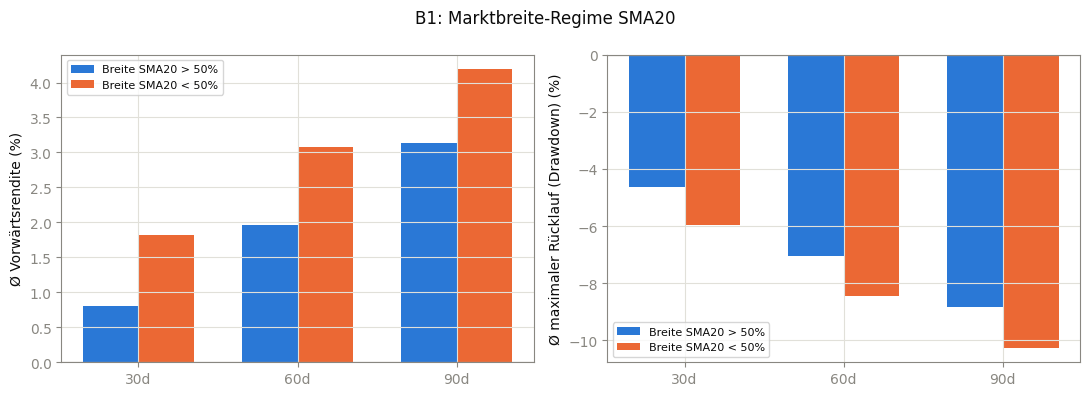

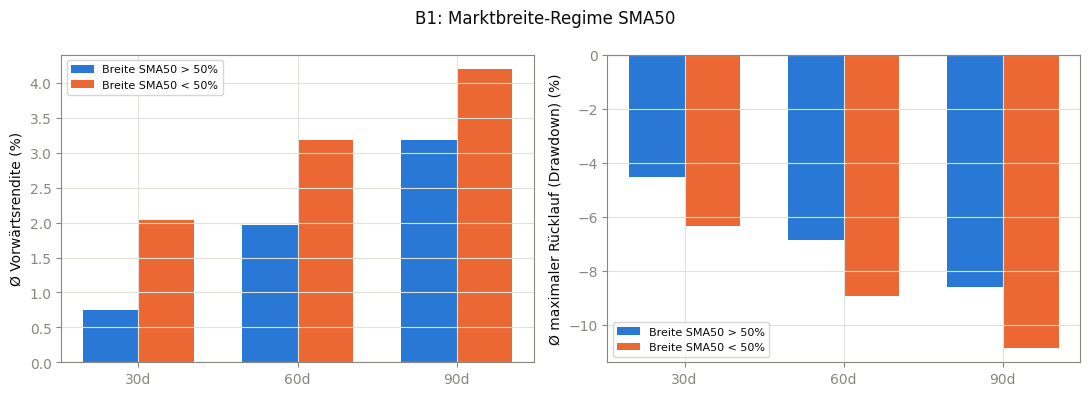

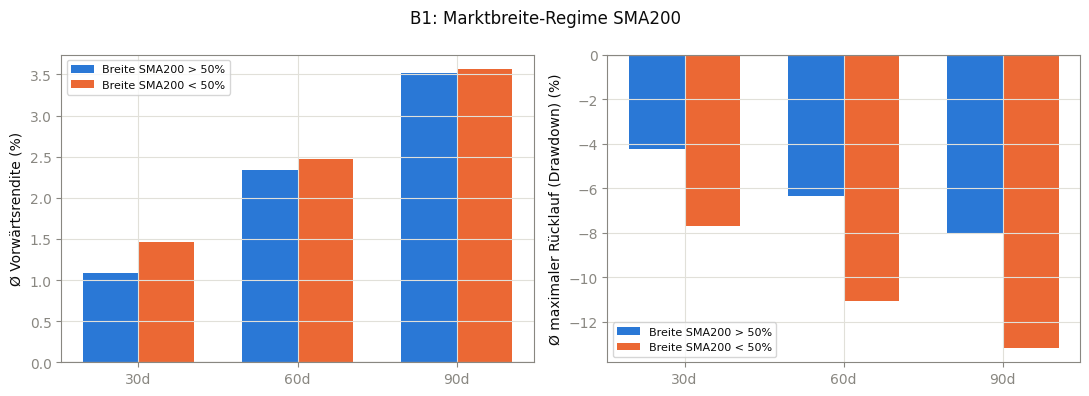

In [13]:
# Diagramm je Fenster
for w in BREADTH_WINDOWS:
    plotte_gruppenvergleich(tabelle_b1[tabelle_b1["sma_fenster"] == w], f"B1: Marktbreite-Regime SMA{w}")


**Ergebnis:** Das Risikosignal ist über alle drei Fenster durchgehend
signifikant (9 von 9 Kombinationen) - notiert die Mehrheit der Mitglieder
unter ihrem SMA, ist der nachfolgende maximale Rücklauf des Gesamtindex in
jedem Fenster und Horizont stärker als bei Breite > 50 %. Das
Renditesignal ist dagegen uneinheitlich: Bei SMA20/50 fällt die mittlere
Vorwärtsrendite bei Breite > 50 % durchgängig **niedriger** aus als bei
Breite < 50 % (Mean-Reversion, signifikant in 6 von 6 Kombinationen); bei
SMA200 nähern sich beide Gruppen an und der Unterschied ist in keinem der
drei Horizonte signifikant (p zwischen 0,12 und 0,90). Über alle Fenster
hinweg zeigt sich die Marktbreite damit als deutlich robusteres
Risikosignal denn als Renditesignal.


### 4.2 B2 - Richtung der Marktbreite (steigend vs. fallend)

**Hypothese:** Unabhängig vom Niveau der Marktbreite könnte bereits ihre
Richtung (nimmt die Beteiligung gerade zu oder ab?) Information über die
Folgeperiode liefern - analog zur SMA-Hypothese H2 (Richtung des Index-SMA).


In [14]:
def breite_richtung(fenster: int) -> tuple[pd.Series, pd.Series]:
    breite_diff = df[f"breite_sma{fenster}"].diff()
    steigend = breite_diff > 0
    fallend = breite_diff <= 0
    return steigend, fallend


ergebnisse_b2 = []
for w in BREADTH_WINDOWS:
    steigend, fallend = breite_richtung(w)
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[steigend, f"{ziel}_{h}d"], df.loc[fallend, f"{ziel}_{h}d"],
                label_a=f"Breite SMA{w} steigend", label_b=f"Breite SMA{w} fallend",
            )
            if res:
                res.update({"sma_fenster": w, "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_b2.append(res)

tabelle_b2 = ergebnisse_zu_tabelle(ergebnisse_b2)
alle_ergebnisse["B2_Breite_Richtung"] = tabelle_b2
tabelle_b2[spalten_anzeige]


,sma_fenster,horizont_tage,zielgröße,label_a,mean_a,label_b,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,30,fwd_return,Breite SMA20 steigend,0.0106,Breite SMA20 fallend,0.0131,0.1160,0.1187,False
1,20,30,fwd_mdd,Breite SMA20 steigend,-0.0510,Breite SMA20 fallend,-0.0515,0.7165,0.3962,False
2,20,60,fwd_return,Breite SMA20 steigend,0.0217,Breite SMA20 fallend,0.0256,0.0771,0.2594,False
3,20,60,fwd_mdd,Breite SMA20 steigend,-0.0760,Breite SMA20 fallend,-0.0753,0.6734,0.7873,False
4,20,90,fwd_return,Breite SMA20 steigend,0.0338,Breite SMA20 fallend,0.0366,0.3021,0.5189,False
5,20,90,fwd_mdd,Breite SMA20 steigend,-0.0936,Breite SMA20 fallend,-0.0935,0.9409,0.6927,False
6,50,30,fwd_return,Breite SMA50 steigend,0.0104,Breite SMA50 fallend,0.0132,0.0803,0.1499,False
7,50,30,fwd_mdd,Breite SMA50 steigend,-0.0505,Breite SMA50 fallend,-0.0521,0.2340,0.0751,False
8,50,60,fwd_return,Breite SMA50 steigend,0.0219,Breite SMA50 fallend,0.0255,0.1044,0.4212,False
9,50,60,fwd_mdd,Breite SMA50 steigend,-0.0752,Breite SMA50 fallend,-0.0760,0.6596,0.4467,False


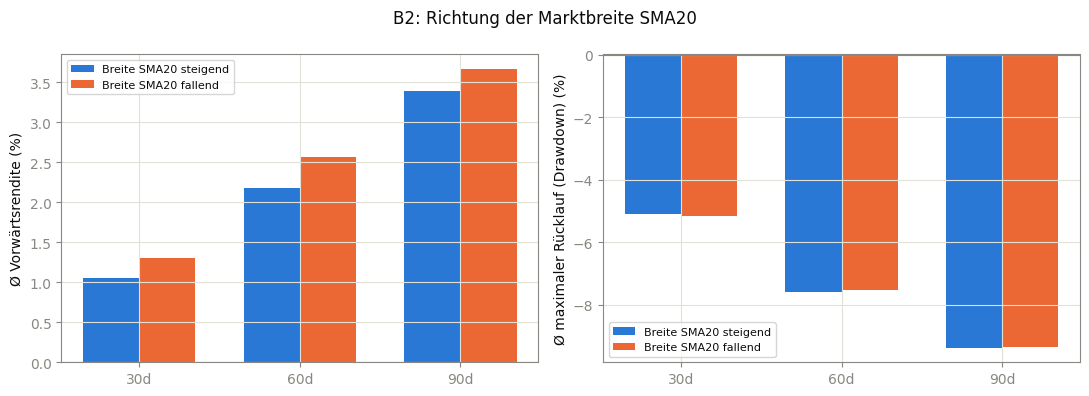

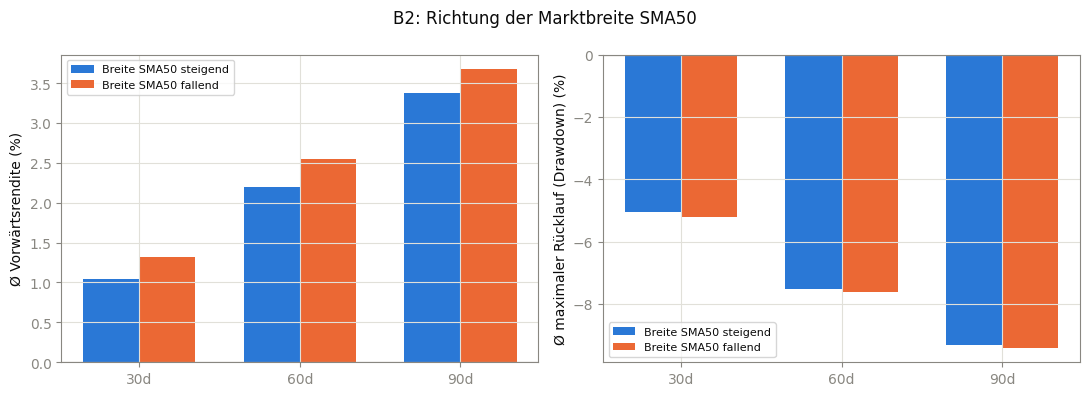

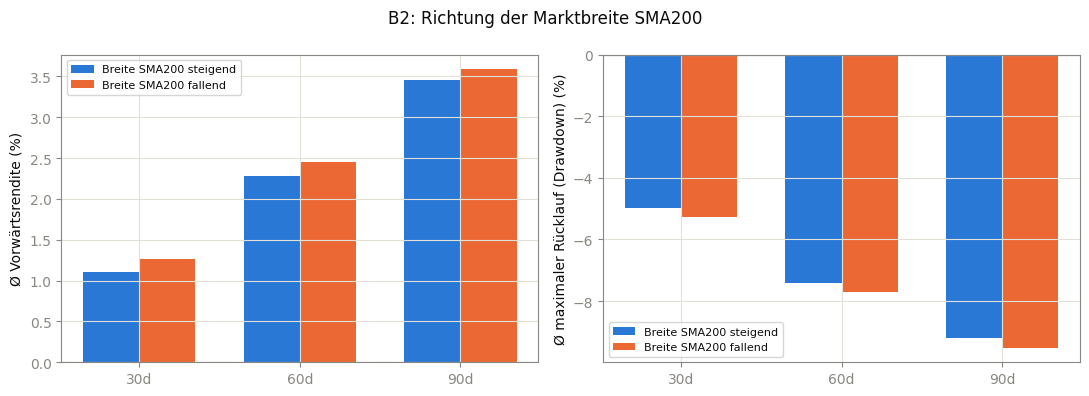

In [15]:
for w in BREADTH_WINDOWS:
    plotte_gruppenvergleich(tabelle_b2[tabelle_b2["sma_fenster"] == w], f"B2: Richtung der Marktbreite SMA{w}")


**Ergebnis:** Anders als das *Niveau* der Marktbreite (B1) liefert ihre
*Richtung* kaum eigenständige Information: Von 18 geprüften Kombinationen
ist nur eine einzige signifikant (SMA200, 30-Tage-Drawdown). Insbesondere
beim Risikosignal - bei B1 durchgehend robust - zeigt sich bei B2 praktisch
kein Unterschied zwischen steigender und fallender Breite. Anders als beim
Niveau der Marktbreite lässt sich hier kein belastbares Signal ableiten -
vermutlich, weil die tägliche Richtungsänderung einer bereits stark
geglätteten Prozentkennzahl in hohem Maß Rauschen statt Trend abbildet.


### 4.3 B3 - Marktbreite in Quartilen

**Hypothese:** Die Wirkung der Marktbreite ist nicht binär, sondern
graduell abgestuft: Je höher die Breite (Q4 = 75-100 %), desto günstiger
das Rendite-/Risikoprofil der Folgeperiode; je niedriger (Q1 = 0-25 %), desto
ungünstiger. Getestet wird mit einem Kruskal-Wallis-Omnibustest über alle
vier Quartile sowie einem paarweisen Extremvergleich Q1 vs. Q4.


In [16]:
def breite_quartil(fenster: int) -> pd.Series:
    breite = df[f"breite_sma{fenster}"]
    return pd.cut(breite, bins=QUARTIL_GRENZEN, labels=QUARTIL_LABELS, include_lowest=True)


ergebnisse_b3 = []
for w in BREADTH_WINDOWS:
    quartil = breite_quartil(w)
    df[f"Quartil_SMA{w}"] = quartil
    print(f"SMA{w} - Verteilung der Handelstage auf die Quartile:")
    print(quartil.value_counts().reindex(QUARTIL_LABELS))
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            gruppen = {label: df.loc[quartil == label, f"{ziel}_{h}d"] for label in QUARTIL_LABELS}
            res = vergleiche_quartile(gruppen)
            if res:
                res.update({"sma_fenster": w, "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_b3.append(res)

tabelle_b3 = ergebnisse_zu_tabelle(ergebnisse_b3)
alle_ergebnisse["B3_Breite_Quartile"] = tabelle_b3
cols_b3 = ["sma_fenster", "horizont_tage", "zielgröße"] + [f"mean_{l}" for l in QUARTIL_LABELS] + \
          ["kw_pvalue", "kw_signifikant_5pct", "q1_vs_q4_signifikant_5pct"]
tabelle_b3[cols_b3]


SMA20 - Verteilung der Handelstage auf die Quartile:
breite_sma20
Q1 (0-25%)       638
Q2 (25-50%)     1174
Q3 (50-75%)     2016
Q4 (75-100%)    1099
Name: count, dtype: int64
SMA50 - Verteilung der Handelstage auf die Quartile:
breite_sma50
Q1 (0-25%)       486
Q2 (25-50%)     1150
Q3 (50-75%)     2216
Q4 (75-100%)    1075
Name: count, dtype: int64
SMA200 - Verteilung der Handelstage auf die Quartile:
breite_sma200
Q1 (0-25%)       344
Q2 (25-50%)      918
Q3 (50-75%)     2319
Q4 (75-100%)    1346
Name: count, dtype: int64


,sma_fenster,horizont_tage,zielgröße,mean_Q1 (0-25%),mean_Q2 (25-50%),mean_Q3 (50-75%),mean_Q4 (75-100%),kw_pvalue,kw_signifikant_5pct,q1_vs_q4_signifikant_5pct
0,20,30,fwd_return,0.0291,0.0124,0.0071,0.0098,0.0000,True,True
1,20,30,fwd_mdd,-0.0678,-0.0554,-0.0459,-0.0470,0.0000,True,True
2,20,60,fwd_return,0.0457,0.0225,0.0167,0.0247,0.0000,True,True
3,20,60,fwd_mdd,-0.0930,-0.0800,-0.0715,-0.0682,0.0000,True,True
4,20,90,fwd_return,0.0542,0.0351,0.0261,0.0407,0.0000,True,True
5,20,90,fwd_mdd,-0.1130,-0.0968,-0.0912,-0.0829,0.0000,True,True
6,50,30,fwd_return,0.0381,0.0129,0.0063,0.0101,0.0000,True,True
7,50,30,fwd_mdd,-0.0752,-0.0583,-0.0457,-0.0443,0.0000,True,True
8,50,60,fwd_return,0.0470,0.0254,0.0167,0.0255,0.0000,True,True
9,50,60,fwd_mdd,-0.1048,-0.0830,-0.0706,-0.0648,0.0000,True,True


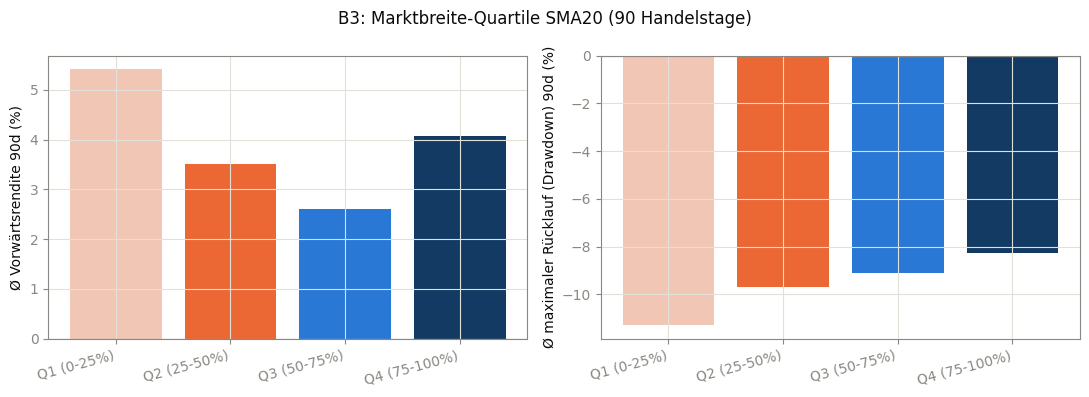

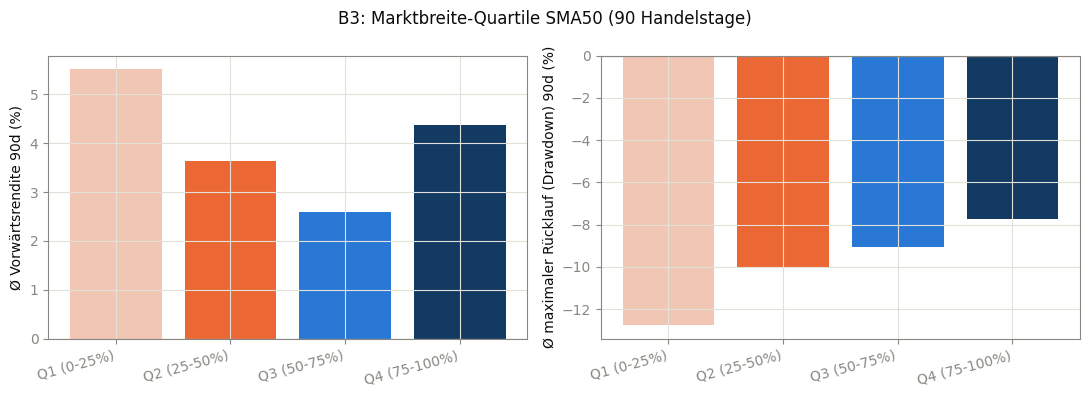

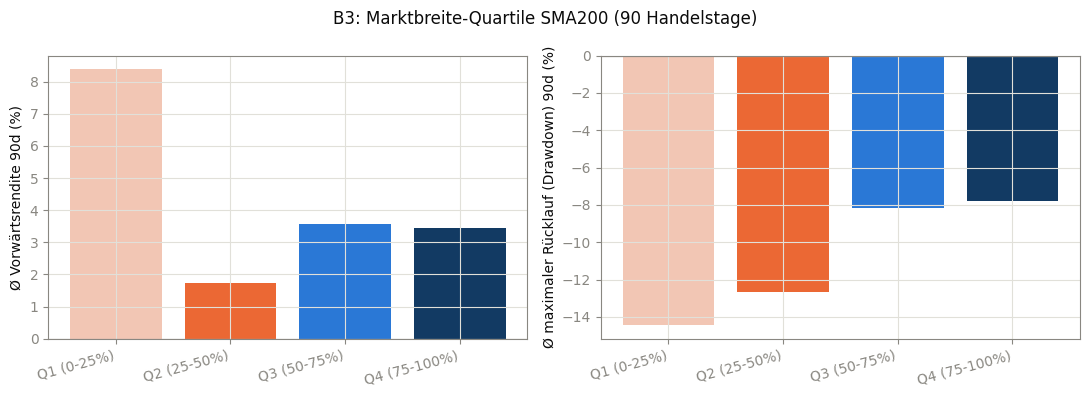

In [17]:
for w in BREADTH_WINDOWS:
    teil_b3 = tabelle_b3[tabelle_b3["sma_fenster"] == w]
    plotte_quartile(teil_b3, 90, f"B3: Marktbreite-Quartile SMA{w} (90 Handelstage)")


**Ergebnis:** Alle 18 Kruskal-Wallis-Omnibustests sind signifikant - die
Marktbreite differenziert die Folgeperiode in jedem Fenster und Horizont
über die vier Quartile hinweg. Das Muster ist jedoch nicht durchgehend
linear: Beim Risiko zeigt sich, besonders deutlich bei SMA200, ein sauberer
monotoner Gradient von Q1 (schwächste Breite, im Mittel größter
90-Tage-Drawdown von -14,5 %) bis Q4 (stärkste Breite, -7,8 %). Bei der
Rendite dominiert dagegen vor allem Q1: Die extrem schwache Breite in Q1
geht mit der **höchsten** mittleren Vorwärtsrendite aller vier Quartile
einher (SMA200/90 Tage: 8,4 % gegenüber 1,7-3,4 % in Q2-Q4) - ein
Extremquartil-Effekt, bei dem hohe erwartete Rendite und hohes Risiko
gemeinsam auftreten, während sich Q2 bis Q4 vor allem im Risiko, kaum aber
in der Rendite unterscheiden.


### 4.4 B4 - Frühindikator Krise

**Hypothese:** Ausgangslage ist eine breit getragene Rally (SMA200-Breite
> 75 %, bei intaktem SMA20-Breitewert von mindestens 50 %). Fällt die
schnelle SMA20-Breite anschließend unter 50 %, während die träge
SMA200-Breite selbst noch nicht unter 50 % gefallen ist, deutet dies auf eine
beginnende, aber von der breiten Marktlage noch nicht bestätigte Abkühlung
hin - ein möglicher Frühindikator für eine bevorstehende Krise.


In [18]:
def frühindikator_krise(breite_sma20: pd.Series, breite_sma200: pd.Series) -> pd.Series:
    '''Signalisiert den Tag, an dem die SMA20-Breite erstmals unter 50 %
    fällt, nachdem die SMA200-Breite zuvor (bei damals noch >= 50 % liegender
    SMA20-Breite) das obere Quartil (> 75 %) erreicht hatte und selbst noch
    nicht unter 50 % gefallen ist.'''
    signal = pd.Series(False, index=breite_sma20.index)
    war_oben = False
    for datum in breite_sma20.index:
        b20, b200 = breite_sma20[datum], breite_sma200[datum]
        if pd.isna(b20) or pd.isna(b200):
            continue
        if b200 <= 50:
            war_oben = False
            continue
        if b200 > 75 and b20 >= 50:
            war_oben = True
        if war_oben and b20 < 50:
            signal[datum] = True
            war_oben = False
    return signal


signal_b4 = frühindikator_krise(df["breite_sma20"], df["breite_sma200"])
n_b4 = int(signal_b4.sum())
print(f"B4-Ereignisse identifiziert: {n_b4}")
if n_b4 > 0:
    print(df.index[signal_b4].date)


B4-Ereignisse identifiziert: 111
[datetime.date(2007, 2, 27) datetime.date(2007, 5, 10)
 datetime.date(2007, 5, 24) datetime.date(2007, 6, 6)
 datetime.date(2007, 6, 20) datetime.date(2007, 7, 10)
 datetime.date(2007, 7, 24) datetime.date(2009, 8, 17)
 datetime.date(2009, 9, 1) datetime.date(2009, 10, 1)
 datetime.date(2009, 10, 26) datetime.date(2009, 11, 27)
 datetime.date(2009, 12, 8) datetime.date(2010, 1, 21)
 datetime.date(2010, 4, 27) datetime.date(2010, 4, 30)
 datetime.date(2010, 5, 4) datetime.date(2010, 11, 16)
 datetime.date(2010, 11, 23) datetime.date(2011, 1, 28)
 datetime.date(2011, 2, 23) datetime.date(2011, 3, 1)
 datetime.date(2011, 3, 7) datetime.date(2011, 3, 10)
 datetime.date(2011, 3, 22) datetime.date(2011, 4, 18)
 datetime.date(2011, 5, 16) datetime.date(2011, 5, 20)
 datetime.date(2011, 6, 1) datetime.date(2011, 7, 14)
 datetime.date(2012, 3, 5) datetime.date(2012, 4, 4)
 datetime.date(2012, 5, 4) datetime.date(2012, 9, 25)
 datetime.date(2013, 2, 21) datetime.

In [19]:
ergebnisse_b4 = []
if n_b4 >= 10:
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[signal_b4, f"{ziel}_{h}d"], df[f"{ziel}_{h}d"],
                label_a="B4-Signal", label_b="Basisrate (alle Tage)",
            )
            if res:
                res.update({"horizont_tage": h, "zielgröße": ziel, "n_events": n_b4})
                ergebnisse_b4.append(res)
    tabelle_b4 = ergebnisse_zu_tabelle(ergebnisse_b4)
else:
    # Zu wenige Ereignisse für einen belastbaren Test - Einzelereignisse
    # werden stattdessen deskriptiv mit ihrer tatsächlichen Folgeentwicklung
    # aufgelistet.
    einzelereignisse = df.loc[signal_b4, [f"fwd_return_{h}d" for h in HORIZONS] + [f"fwd_mdd_{h}d" for h in HORIZONS]]
    tabelle_b4 = einzelereignisse.reset_index()
    print(f"Nur {n_b4} Ereignisse - deskriptive Einzelbetrachtung statt Signifikanztest:")

alle_ergebnisse["B4_Frühindikator_Krise"] = tabelle_b4
tabelle_b4


,label_a,n_a,mean_a,median_a,std_a,label_b,n_b,mean_b,median_b,std_b,t_pvalue,u_pvalue,signifikant_5pct,horizont_tage,zielgröße,n_events
0,B4-Signal,111,0.0194,0.0234,0.0445,Basisrate (alle Tage),4900,0.0118,0.0183,0.0561,0.0814,0.0994,False,30,fwd_return,111
1,B4-Signal,111,-0.0420,-0.0337,0.0386,Basisrate (alle Tage),4900,-0.0513,-0.0390,0.0461,0.0146,0.0367,True,30,fwd_mdd,111
2,B4-Signal,111,0.0265,0.0322,0.0583,Basisrate (alle Tage),4870,0.0237,0.0347,0.0764,0.6170,0.9163,False,60,fwd_return,111
3,B4-Signal,111,-0.0626,-0.0508,0.0495,Basisrate (alle Tage),4870,-0.0756,-0.0569,0.0621,0.0074,0.0311,True,60,fwd_mdd,111
4,B4-Signal,111,0.0435,0.0497,0.0629,Basisrate (alle Tage),4840,0.0353,0.0477,0.0932,0.1783,0.4558,False,90,fwd_return,111
5,B4-Signal,111,-0.0745,-0.0576,0.0562,Basisrate (alle Tage),4840,-0.0935,-0.0720,0.0727,0.0007,0.0016,True,90,fwd_mdd,111


**Ergebnis:** Mit 111 identifizierten Ereignissen seit 2007 ist das Muster
gut testbar - das Resultat widerspricht der Hypothese jedoch. Der maximale
Vorwärtsrücklauf ist nach dem Signal in allen drei Horizonten
signifikant **kleiner** (nicht größer) als die Basisrate (30 Tage: -4,2 %
gegenüber -5,1 %; 60 Tage: -6,3 % gegenüber -7,6 %; 90 Tage: -7,5 %
gegenüber -9,4 %), die Vorwärtsrendite liegt zugleich - wenn auch nicht
signifikant - leicht **höher** als die Basisrate. In den historischen
Daten ging dem Muster "breit getragene Rally, dann bricht die schnelle
SMA20-Breite unter 50 % ein" damit im Mittel eine ruhigere, nicht
turbulentere Folgeperiode voraus. Die als Frühindikator einer Krise
formulierte Hypothese bestätigt sich in den Daten des S&P 500 **nicht** -
plausibler ist, dass ein kurzzeitiger Rücksetzer der schnellen Breite bei
intakter breiter Beteiligung eher eine gesunde Verschnaufpause innerhalb
eines laufenden Aufwärtstrends markiert (vgl. die ähnliche
Mean-Reversion-Wirkung bei B1, B3, B6, B8 und B9). Mit 111 Ereignissen in
nicht ganz 20 Jahren (im Schnitt etwa alle zwei Monate) ist das Muster
zudem ohnehin deutlich häufiger, als der Name "Frühindikator Krise"
vermuten lässt.


### 4.5 B5 - Frühindikator Erholung

**Hypothese:** Spiegelbild zu B4. Ausgangslage ist eine breit unterstützte
Schwächephase (SMA200-Breite < 25 %, bei damals noch schwacher
SMA20-Breite <= 50 %). Steigt die schnelle SMA20-Breite anschließend über
50 %, während die SMA200-Breite selbst noch nicht über 50 % gestiegen ist,
deutet dies auf eine beginnende, breitenseitig noch nicht bestätigte
Erholung hin.


In [20]:
def frühindikator_erholung(breite_sma20: pd.Series, breite_sma200: pd.Series) -> pd.Series:
    signal = pd.Series(False, index=breite_sma20.index)
    war_unten = False
    for datum in breite_sma20.index:
        b20, b200 = breite_sma20[datum], breite_sma200[datum]
        if pd.isna(b20) or pd.isna(b200):
            continue
        if b200 >= 50:
            war_unten = False
            continue
        if b200 < 25 and b20 <= 50:
            war_unten = True
        if war_unten and b20 > 50:
            signal[datum] = True
            war_unten = False
    return signal


signal_b5 = frühindikator_erholung(df["breite_sma20"], df["breite_sma200"])
n_b5 = int(signal_b5.sum())
print(f"B5-Ereignisse identifiziert: {n_b5}")
if n_b5 > 0:
    print(df.index[signal_b5].date)


B5-Ereignisse identifiziert: 33
[datetime.date(2008, 1, 31) datetime.date(2008, 2, 11)
 datetime.date(2008, 3, 24) datetime.date(2008, 10, 31)
 datetime.date(2008, 11, 28) datetime.date(2008, 12, 5)
 datetime.date(2008, 12, 26) datetime.date(2008, 12, 30)
 datetime.date(2009, 1, 28) datetime.date(2009, 2, 5)
 datetime.date(2009, 3, 12) datetime.date(2011, 8, 29)
 datetime.date(2011, 9, 7) datetime.date(2011, 9, 13)
 datetime.date(2011, 10, 6) datetime.date(2011, 10, 10)
 datetime.date(2011, 11, 30) datetime.date(2015, 9, 15)
 datetime.date(2015, 10, 5) datetime.date(2016, 1, 29)
 datetime.date(2016, 2, 16) datetime.date(2019, 1, 7)
 datetime.date(2020, 4, 6) datetime.date(2020, 5, 7)
 datetime.date(2020, 5, 18) datetime.date(2022, 5, 26)
 datetime.date(2022, 7, 7) datetime.date(2022, 7, 15)
 datetime.date(2022, 7, 19) datetime.date(2022, 10, 17)
 datetime.date(2022, 10, 21) datetime.date(2023, 11, 2)
 datetime.date(2025, 4, 24)]


In [21]:
ergebnisse_b5 = []
if n_b5 >= 10:
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[signal_b5, f"{ziel}_{h}d"], df[f"{ziel}_{h}d"],
                label_a="B5-Signal", label_b="Basisrate (alle Tage)",
            )
            if res:
                res.update({"horizont_tage": h, "zielgröße": ziel, "n_events": n_b5})
                ergebnisse_b5.append(res)
    tabelle_b5 = ergebnisse_zu_tabelle(ergebnisse_b5)
else:
    einzelereignisse = df.loc[signal_b5, [f"fwd_return_{h}d" for h in HORIZONS] + [f"fwd_mdd_{h}d" for h in HORIZONS]]
    tabelle_b5 = einzelereignisse.reset_index()
    print(f"Nur {n_b5} Ereignisse - deskriptive Einzelbetrachtung statt Signifikanztest:")

alle_ergebnisse["B5_Frühindikator_Erholung"] = tabelle_b5
tabelle_b5


,label_a,n_a,mean_a,median_a,std_a,label_b,n_b,mean_b,median_b,std_b,t_pvalue,u_pvalue,signifikant_5pct,horizont_tage,zielgröße,n_events
0,B5-Signal,33,0.0208,0.0409,0.0687,Basisrate (alle Tage),4900,0.0118,0.0183,0.0561,0.4591,0.1886,False,30,fwd_return,33
1,B5-Signal,33,-0.0819,-0.0712,0.0599,Basisrate (alle Tage),4900,-0.0513,-0.0390,0.0461,0.0062,0.0001,True,30,fwd_mdd,33
2,B5-Signal,33,0.0325,0.0389,0.1028,Basisrate (alle Tage),4870,0.0237,0.0347,0.0764,0.6270,0.3461,False,60,fwd_return,33
3,B5-Signal,33,-0.1148,-0.0875,0.0798,Basisrate (alle Tage),4870,-0.0756,-0.0569,0.0621,0.0083,0.0011,True,60,fwd_mdd,33
4,B5-Signal,33,0.0636,0.0780,0.1012,Basisrate (alle Tage),4840,0.0353,0.0477,0.0932,0.1182,0.1178,False,90,fwd_return,33
5,B5-Signal,33,-0.1300,-0.0984,0.0846,Basisrate (alle Tage),4840,-0.0935,-0.0720,0.0727,0.0188,0.0034,True,90,fwd_mdd,33


**Ergebnis:** 33 Ereignisse seit 2007, historisch plausibel rund um reale
Bodenbildungsphasen konzentriert (2008/2009, 2011, 2015/2016, 2020, 2022).
Die Vorwärtsrendite liegt im Mittel durchgehend höher als die Basisrate
(30 Tage: 2,1 % gegenüber 1,2 %; 90 Tage: 6,4 % gegenüber 3,5 %), jedoch
in keinem Horizont signifikant (kleine Stichprobe). Der maximale
Vorwärtsrücklauf ist dagegen in allen drei Horizonten signifikant
**größer** als die Basisrate (30 Tage: -8,2 % gegenüber -5,1 %; 90 Tage:
-13,0 % gegenüber -9,4 %) - also das Gegenteil dessen, was eine "ruhige
Erholung" nahelegen würde. Das Signal markiert damit plausibel den Beginn
einer Stabilisierung (leicht höhere Rendite), tritt aber innerhalb noch
volatiler Bodenbildungsphasen auf, in denen das Schwankungsrisiko zunächst
erhöht bleibt - eher ein früher Hinweis auf eine unruhige Bodenbildung als
ein Signal für eine risikoarme Erholung.


### 4.6 Gemeinsames Vorgehen für B6-B9

Die folgenden vier Hypothesen basieren alle auf punktuellen Ereignissen
(Schwellenkreuzungen). Sie werden mit derselben Funktion ausgewertet: Bei
mindestens 10 Ereignissen wird das Ereignis gegen die Basisrate (alle
Handelstage) getestet, bei weniger Ereignissen erfolgt eine deskriptive
Auflistung der Einzelereignisse.


In [22]:
def ereignis_hypothese(event: pd.Series, label: str, extra: dict) -> tuple[list[dict], pd.DataFrame | None]:
    '''Testet ein Ereignis (event=True an den Signaltagen) gegen die
    Basisrate aller Handelstage. Liefert (Ergebnisliste, None) bei
    ausreichender Stichprobe, sonst (leere Liste, Tabelle der
    Einzelereignisse) zur deskriptiven Auflistung.'''
    n = int(event.sum())
    if n >= 10:
        ergebnisse = []
        for h in HORIZONS:
            for ziel in ["fwd_return", "fwd_mdd"]:
                res = vergleiche_gruppen(
                    df.loc[event, f"{ziel}_{h}d"], df[f"{ziel}_{h}d"],
                    label_a=label, label_b="Basisrate (alle Tage)",
                )
                if res:
                    res.update({**extra, "horizont_tage": h, "zielgröße": ziel, "n_events": n})
                    ergebnisse.append(res)
        return ergebnisse, None
    else:
        spalten = [f"fwd_return_{h}d" for h in HORIZONS] + [f"fwd_mdd_{h}d" for h in HORIZONS]
        einzel = df.loc[event, spalten].reset_index()
        for k, v in extra.items():
            einzel[k] = v
        return [], einzel


print("Gemeinsame Ereignis-Testfunktion definiert.")


Gemeinsame Ereignis-Testfunktion definiert.


### 4.7 B6 - Wochentrend positiv, Marktbreite bricht ein

**Hypothese:** Steigt der Index auf Wochenbasis (Kurs > SMA50_w, ca. 1 Jahr),
die Marktbreite je SMA-Fenster jedoch gleichzeitig (a) aus dem oberen
Quartil heraus oder (b) unter 50 % - deutet dies auf eine zunehmend schmaler
getragene Rally hin, obwohl der Index selbst noch keinen Trendbruch zeigt.
Jedes Fenster (SMA20/50/200) wird einzeln betrachtet.


In [23]:
def kreuzt_abwärts(reihe: pd.Series, schwelle: float) -> pd.Series:
    vorher = reihe.shift(1)
    return (vorher >= schwelle) & (reihe < schwelle)


wochentrend_positiv = df["Wochentrend_positiv"] == 1

ergebnisse_b6 = []
deskriptiv_b6 = []
n_events_b6 = {}
for w in BREADTH_WINDOWS:
    breite = df[f"breite_sma{w}"]
    for schwelle, bezeichnung in [(75, "verlässt oberes Quartil (75%)"), (50, "fällt unter 50%")]:
        event = kreuzt_abwärts(breite, schwelle) & wochentrend_positiv
        label = f"B6 SMA{w} {bezeichnung}"
        n_events_b6[label] = int(event.sum())
        ergebnisse, deskriptiv = ereignis_hypothese(
            event, label, {"sma_fenster": w, "schwelle": schwelle, "bezeichnung": bezeichnung},
        )
        ergebnisse_b6.extend(ergebnisse)
        if deskriptiv is not None:
            deskriptiv_b6.append(deskriptiv)

print("Ereignishäufigkeit je Parametrisierung:")
for label, n in n_events_b6.items():
    print(f"  {label:.<55s} {n}")

tabelle_b6 = ergebnisse_zu_tabelle(ergebnisse_b6)
alle_ergebnisse["B6_Wochentrend_positiv_Breiteneinbruch"] = tabelle_b6
tabelle_deskriptiv_b6 = pd.concat(deskriptiv_b6, ignore_index=True) if deskriptiv_b6 else pd.DataFrame()
if not tabelle_b6.empty:
    display(tabelle_b6[["sma_fenster", "bezeichnung", "n_events", "horizont_tage", "zielgröße",
                         "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]])
if not tabelle_deskriptiv_b6.empty:
    print("\nDeskriptiv (weniger als 10 Ereignisse):")
    display(tabelle_deskriptiv_b6)


Ereignishäufigkeit je Parametrisierung:
  B6 SMA20 verlässt oberes Quartil (75%)................. 169
  B6 SMA20 fällt unter 50%............................... 229
  B6 SMA50 verlässt oberes Quartil (75%)................. 115
  B6 SMA50 fällt unter 50%............................... 137
  B6 SMA200 verlässt oberes Quartil (75%)................ 78
  B6 SMA200 fällt unter 50%.............................. 48


,sma_fenster,bezeichnung,n_events,horizont_tage,zielgröße,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,verlässt oberes Quartil (75%),169,30,fwd_return,0.0111,0.0118,0.8333,0.7729,False
1,20,verlässt oberes Quartil (75%),169,30,fwd_mdd,-0.0439,-0.0513,0.0039,0.1762,False
2,20,verlässt oberes Quartil (75%),169,60,fwd_return,0.0193,0.0237,0.3909,0.4605,False
3,20,verlässt oberes Quartil (75%),169,60,fwd_mdd,-0.0678,-0.0756,0.0722,0.1013,False
4,20,verlässt oberes Quartil (75%),169,90,fwd_return,0.0366,0.0353,0.8028,0.6421,False
5,20,verlässt oberes Quartil (75%),169,90,fwd_mdd,-0.0819,-0.0935,0.0145,0.0681,False
6,20,fällt unter 50%,229,30,fwd_return,0.0173,0.0118,0.0831,0.0621,False
7,20,fällt unter 50%,229,30,fwd_mdd,-0.0417,-0.0513,0.0002,0.0002,True
8,20,fällt unter 50%,229,60,fwd_return,0.0295,0.0237,0.1462,0.4007,False
9,20,fällt unter 50%,229,60,fwd_mdd,-0.0607,-0.0756,0.0000,0.0001,True


**Ergebnis:** Alle sechs Parametrisierungen sind mit 48 bis 229 Ereignissen
gut testbar. Die Rendite unterscheidet sich in keiner Kombination
signifikant von der Basisrate. Beim Risiko zeigt sich ein signifikanter
Unterschied ausschließlich bei SMA20/SMA50 (5 von 12 Kombinationen) -
und zwar in die dem Hypothesentext **entgegengesetzte** Richtung: Der
nachfolgende maximale Rücklauf fällt nach dem Signal kleiner aus als die
Basisrate (z. B. SMA20 "fällt unter 50 %", 90 Tage: -7,4 % gegenüber
-9,4 %). Bei SMA200 ist kein einziger der zwölf Vergleiche signifikant.
Ein sich abschwächender, aber noch positiver Wochentrend liefert damit
kein belastbares Frühwarnsignal über eine schmaler werdende Rally -
soweit überhaupt ein Effekt sichtbar wird, deutet er (wie bereits bei B4)
eher auf eine gesunde Verschnaufpause hin.


### 4.8 B7 - Wochentrend negativ, Marktbreite stabilisiert sich

**Hypothese:** Spiegelbild zu B6. Fällt der Index auf Wochenbasis (Kurs <=
SMA50_w), die Marktbreite je SMA-Fenster jedoch (a) aus dem unteren Quartil
heraus oder (b) über 50 % - deutet dies auf eine zunehmend breiter
getragene Stabilisierung hin, obwohl der Index selbst noch keinen
Trendwechsel zeigt.


In [24]:
def kreuzt_aufwärts(reihe: pd.Series, schwelle: float) -> pd.Series:
    vorher = reihe.shift(1)
    return (vorher <= schwelle) & (reihe > schwelle)


wochentrend_negativ = df["Wochentrend_positiv"] == 0

ergebnisse_b7 = []
deskriptiv_b7 = []
n_events_b7 = {}
for w in BREADTH_WINDOWS:
    breite = df[f"breite_sma{w}"]
    for schwelle, bezeichnung in [(25, "verlässt unteres Quartil (25%)"), (50, "steigt über 50%")]:
        event = kreuzt_aufwärts(breite, schwelle) & wochentrend_negativ
        label = f"B7 SMA{w} {bezeichnung}"
        n_events_b7[label] = int(event.sum())
        ergebnisse, deskriptiv = ereignis_hypothese(
            event, label, {"sma_fenster": w, "schwelle": schwelle, "bezeichnung": bezeichnung},
        )
        ergebnisse_b7.extend(ergebnisse)
        if deskriptiv is not None:
            deskriptiv_b7.append(deskriptiv)

print("Ereignishäufigkeit je Parametrisierung:")
for label, n in n_events_b7.items():
    print(f"  {label:.<55s} {n}")

tabelle_b7 = ergebnisse_zu_tabelle(ergebnisse_b7)
alle_ergebnisse["B7_Wochentrend_negativ_Breitenstabilisierung"] = tabelle_b7
tabelle_deskriptiv_b7 = pd.concat(deskriptiv_b7, ignore_index=True) if deskriptiv_b7 else pd.DataFrame()
if not tabelle_b7.empty:
    display(tabelle_b7[["sma_fenster", "bezeichnung", "n_events", "horizont_tage", "zielgröße",
                         "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]])
if not tabelle_deskriptiv_b7.empty:
    print("\nDeskriptiv (weniger als 10 Ereignisse):")
    display(tabelle_deskriptiv_b7)


Ereignishäufigkeit je Parametrisierung:
  B7 SMA20 verlässt unteres Quartil (25%)................ 70
  B7 SMA20 steigt über 50%............................... 64
  B7 SMA50 verlässt unteres Quartil (25%)................ 47
  B7 SMA50 steigt über 50%............................... 42
  B7 SMA200 verlässt unteres Quartil (25%)............... 34
  B7 SMA200 steigt über 50%.............................. 14


,sma_fenster,bezeichnung,n_events,horizont_tage,zielgröße,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,verlässt unteres Quartil (25%),70,30,fwd_return,0.0064,0.0118,0.6472,0.2372,False
1,20,verlässt unteres Quartil (25%),70,30,fwd_mdd,-0.0892,-0.0513,0.0001,0.0000,True
2,20,verlässt unteres Quartil (25%),70,60,fwd_return,0.0239,0.0237,0.9872,0.3024,False
3,20,verlässt unteres Quartil (25%),70,60,fwd_mdd,-0.1205,-0.0756,0.0002,0.0000,True
4,20,verlässt unteres Quartil (25%),70,90,fwd_return,0.0357,0.0353,0.9801,0.2665,False
5,20,verlässt unteres Quartil (25%),70,90,fwd_mdd,-0.1410,-0.0935,0.0003,0.0000,True
6,20,steigt über 50%,64,30,fwd_return,0.0033,0.0118,0.3872,0.7773,False
7,20,steigt über 50%,64,30,fwd_mdd,-0.0816,-0.0513,0.0001,0.0000,True
8,20,steigt über 50%,64,60,fwd_return,0.0134,0.0237,0.5123,0.4744,False
9,20,steigt über 50%,64,60,fwd_mdd,-0.1208,-0.0756,0.0001,0.0000,True


**Ergebnis:** Ereignishäufigkeiten liegen zwischen 14 und 70 - bis auf die
kleinste Parametrisierung (SMA200 "steigt über 50 %", n=14) durchgehend
gut testbar. Die Rendite unterscheidet sich in keiner der zwölf
Kombinationen signifikant von der Basisrate. Beim Risiko zeigt sich
dagegen ein durchgehend signifikanter Unterschied bei SMA20/SMA50 (10 von
12) sowie teilweise bei SMA200 - und zwar wie schon bei B5 in die
unerwartete Richtung: Der maximale Vorwärtsrücklauf fällt **größer**
statt kleiner aus (z. B. SMA20 "verlässt unteres Quartil", 90 Tage:
-14,1 % gegenüber -9,4 % Basisrate). Ein sich bereits aufhellender, aber
noch negativer Wochentrend geht damit historisch nicht mit einer
risikoärmeren Erholung einher, sondern mit anhaltend erhöhter Volatilität
- inhaltlich dasselbe Muster wie bei B5, hier jedoch mit deutlich größeren
Stichproben statistisch breiter abgesichert.


### 4.9 B8 - Divergenz: Kurshoch ohne Breitenbestätigung

**Hypothese:** Erreicht der Index ein neues Hoch der letzten w Handelstage,
ist relevant, ob die zugehörige Marktbreite (SMA-Fenster w) diese Bewegung
bestätigt (in den letzten 10 Handelstagen gestiegen) oder nicht (gefallen
oder unverändert). Eine unbestätigte Rally (steigender Kurs, fallende
Beteiligung) gilt in der technischen Analyse als Warnsignal.


In [25]:
DIVERGENZ_LAG = 10

ergebnisse_b8 = []
deskriptiv_b8 = []
for w in BREADTH_WINDOWS:
    breite = df[f"breite_sma{w}"]
    kurshoch = df["Close"] >= df["Close"].rolling(window=w, min_periods=w).max()
    bestätigt = kurshoch & (breite > breite.shift(DIVERGENZ_LAG))
    nicht_bestätigt = kurshoch & (breite <= breite.shift(DIVERGENZ_LAG))
    print(f"SMA{w}: {int(kurshoch.sum())} {w}-Tage-Hochs, davon "
          f"{int(bestätigt.sum())} breitenbestätigt und {int(nicht_bestätigt.sum())} unbestätigt.")

    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[bestätigt, f"{ziel}_{h}d"], df.loc[nicht_bestätigt, f"{ziel}_{h}d"],
                label_a=f"{w}-Tage-Hoch, Breite bestätigt", label_b=f"{w}-Tage-Hoch, Breite nicht bestätigt",
            )
            if res:
                res.update({"sma_fenster": w, "horizont_tage": h, "zielgröße": ziel,
                             "n_bestätigt": int(bestätigt.sum()), "n_nicht_bestätigt": int(nicht_bestätigt.sum())})
                ergebnisse_b8.append(res)

    if int(bestätigt.sum()) < 10 or int(nicht_bestätigt.sum()) < 10:
        spalten = [f"fwd_return_{h}d" for h in HORIZONS] + [f"fwd_mdd_{h}d" for h in HORIZONS]
        einzel = df.loc[kurshoch, spalten + []].reset_index()
        einzel["sma_fenster"] = w
        einzel["breite_bestätigt"] = bestätigt.loc[kurshoch].values
        deskriptiv_b8.append(einzel)

tabelle_b8 = ergebnisse_zu_tabelle(ergebnisse_b8)
alle_ergebnisse["B8_Divergenz_Kurshoch_Breite"] = tabelle_b8
tabelle_deskriptiv_b8 = pd.concat(deskriptiv_b8, ignore_index=True) if deskriptiv_b8 else pd.DataFrame()
if not tabelle_b8.empty:
    display(tabelle_b8[["sma_fenster", "horizont_tage", "zielgröße", "n_bestätigt", "n_nicht_bestätigt",
                         "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]])


SMA20: 1058 20-Tage-Hochs, davon 752 breitenbestätigt und 306 unbestätigt.
SMA50: 826 50-Tage-Hochs, davon 639 breitenbestätigt und 187 unbestätigt.
SMA200: 622 200-Tage-Hochs, davon 490 breitenbestätigt und 132 unbestätigt.


,sma_fenster,horizont_tage,zielgröße,n_bestätigt,n_nicht_bestätigt,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,30,fwd_return,752,306,0.0070,0.0128,0.0441,0.1672,False
1,20,30,fwd_mdd,752,306,-0.0442,-0.0396,0.0449,0.6318,False
2,20,60,fwd_return,752,306,0.0162,0.0238,0.0575,0.4044,False
3,20,60,fwd_mdd,752,306,-0.0689,-0.0612,0.0288,0.2713,False
4,20,90,fwd_return,752,306,0.0266,0.0358,0.0655,0.1495,False
5,20,90,fwd_mdd,752,306,-0.0874,-0.0838,0.4110,0.7545,False
6,50,30,fwd_return,639,187,0.0049,0.0133,0.0205,0.0016,True
7,50,30,fwd_mdd,639,187,-0.0425,-0.0397,0.3559,0.4679,False
8,50,60,fwd_return,639,187,0.0173,0.0209,0.4390,0.5836,False
9,50,60,fwd_mdd,639,187,-0.0640,-0.0654,0.7516,0.2744,False


**Ergebnis:** Die große Mehrheit der Hochs ist breitenbestätigt (SMA20:
752 von 1.058; SMA50: 639 von 826; SMA200: 490 von 622). Das Risiko
unterscheidet sich in keiner der neun Kombinationen signifikant zwischen
bestätigten und unbestätigten Hochs. Bei der Rendite sind drei
Kombinationen signifikant (SMA50, 30 und 90 Tage; SMA200, 90 Tage) - und in
allen drei Fällen fällt die Vorwärtsrendite nach einem **unbestätigten**
Hoch **höher** aus als nach einem breitenbestätigten (SMA50/90 Tage: 3,8 %
gegenüber 2,5 %; SMA200/90 Tage: 3,3 % gegenüber 2,1 %). Die klassische
Warnung vor einer "nicht bestätigten Rally" bestätigt sich in den Daten
des S&P 500 damit **nicht** - im Gegenteil deutet sich ein
Mean-Reversion-Muster an, das zum bereits bei B1/B3/B6 beobachteten Bild
passt.


### 4.10 B9 - Breadth Thrust und Breadth Collapse

**Hypothese:** Ein schneller Anstieg der Marktbreite von unter 40 % auf über
60 % innerhalb von 10 Handelstagen (Breadth Thrust) gilt in der technischen
Analyse als seltenes, aber kräftiges Kaufsignal (Konzept angelehnt an den
Zweig Breadth Thrust). Der Einbruch von über 60 % auf unter 40 % innerhalb
derselben Frist (Breadth Collapse) wäre das entsprechende Warnsignal.


In [26]:
THRUST_FENSTER = 10
THRUST_UNTEN, THRUST_OBEN = 40, 60

ergebnisse_b9 = []
deskriptiv_b9 = []
n_events_b9 = {}
for w in BREADTH_WINDOWS:
    breite = df[f"breite_sma{w}"]
    minimum_vorher = breite.shift(1).rolling(window=THRUST_FENSTER, min_periods=THRUST_FENSTER).min()
    maximum_vorher = breite.shift(1).rolling(window=THRUST_FENSTER, min_periods=THRUST_FENSTER).max()

    thrust = (breite >= THRUST_OBEN) & (minimum_vorher <= THRUST_UNTEN)
    collapse = (breite <= THRUST_UNTEN) & (maximum_vorher >= THRUST_OBEN)

    for event, label in [(thrust, f"B9 SMA{w} Breadth Thrust"), (collapse, f"B9 SMA{w} Breadth Collapse")]:
        n_events_b9[label] = int(event.sum())
        ergebnisse, deskriptiv = ereignis_hypothese(event, label, {"sma_fenster": w, "muster": label})
        ergebnisse_b9.extend(ergebnisse)
        if deskriptiv is not None:
            deskriptiv_b9.append(deskriptiv)

print("Ereignishäufigkeit je Parametrisierung:")
for label, n in n_events_b9.items():
    print(f"  {label:.<40s} {n}")

tabelle_b9 = ergebnisse_zu_tabelle(ergebnisse_b9)
alle_ergebnisse["B9_Breadth_Thrust_Collapse"] = tabelle_b9
tabelle_deskriptiv_b9 = pd.concat(deskriptiv_b9, ignore_index=True) if deskriptiv_b9 else pd.DataFrame()
if not tabelle_b9.empty:
    display(tabelle_b9[["sma_fenster", "muster", "n_events", "horizont_tage", "zielgröße",
                         "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]])
if not tabelle_deskriptiv_b9.empty:
    print("\nDeskriptiv (weniger als 10 Ereignisse):")
    display(tabelle_deskriptiv_b9)


Ereignishäufigkeit je Parametrisierung:
  B9 SMA20 Breadth Thrust................. 806
  B9 SMA20 Breadth Collapse............... 666
  B9 SMA50 Breadth Thrust................. 262
  B9 SMA50 Breadth Collapse............... 231
  B9 SMA200 Breadth Thrust................ 13
  B9 SMA200 Breadth Collapse.............. 31


,sma_fenster,muster,n_events,horizont_tage,zielgröße,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,B9 SMA20 Breadth Thrust,806,30,fwd_return,0.0093,0.0118,0.2320,0.7447,False
1,20,B9 SMA20 Breadth Thrust,806,30,fwd_mdd,-0.0515,-0.0513,0.9013,0.1158,False
2,20,B9 SMA20 Breadth Thrust,806,60,fwd_return,0.0204,0.0237,0.2763,0.6730,False
3,20,B9 SMA20 Breadth Thrust,806,60,fwd_mdd,-0.0753,-0.0756,0.9071,0.1009,False
4,20,B9 SMA20 Breadth Thrust,806,90,fwd_return,0.0326,0.0353,0.4394,0.2179,False
5,20,B9 SMA20 Breadth Thrust,806,90,fwd_mdd,-0.0924,-0.0935,0.7001,0.3427,False
6,20,B9 SMA20 Breadth Collapse,666,30,fwd_return,0.0209,0.0118,0.0004,0.0000,True
7,20,B9 SMA20 Breadth Collapse,666,30,fwd_mdd,-0.0593,-0.0513,0.0002,0.0000,True
8,20,B9 SMA20 Breadth Collapse,666,60,fwd_return,0.0344,0.0237,0.0008,0.0004,True
9,20,B9 SMA20 Breadth Collapse,666,60,fwd_mdd,-0.0808,-0.0756,0.0406,0.0029,True


**Ergebnis:** Breadth Thrust (rasche Ausweitung) ist bei SMA20/SMA50 in
keiner Kombination signifikant; bei SMA200 (nur 13 Ereignisse) deutet sich
richtungsgleich ein Effekt an, bleibt aber wegen der kleinen Stichprobe
unter der Signifikanzschwelle. **Breadth Collapse** (rascher Einbruch)
zeigt dagegen bei SMA20 (666 Ereignisse) und SMA50 (231 Ereignisse) ein
klares Muster: Sowohl die Vorwärtsrendite als auch das Risiko sind
signifikant **höher** als die Basisrate (SMA20/90 Tage: Rendite 4,5 %
gegenüber 3,5 %, Drawdown -10,0 % gegenüber -9,4 %) - ein rascher
Breiteneinbruch fällt historisch mit kurzfristigen Panikphasen zusammen,
auf die im Mittel eine überdurchschnittliche Erholung folgt, allerdings bei
gleichzeitig erhöhtem Risiko. Bei SMA200 (nur 31 Collapse-Ereignisse) zeigt
sich dieselbe Richtung, jedoch nur teilweise signifikant. Anders als bei
B4/B6/B8 ist hier die Rendite, nicht nur das Risiko, robust betroffen - ein
klassisches Risiko-Rendite-Muster statt eines reinen Warnsignals.


### 4.11 Übergreifende Robustheitsübersicht

Fasst über alle getesteten Parametrisierungen je Hypothese den Anteil
signifikanter Kombinationen zusammen - getrennt für Rendite und Risiko.
Ereignishypothesen mit weniger als 10 Fällen (nur deskriptiv ausgewiesen)
tragen keine testbaren Zeilen bei und erscheinen daher ggf. nicht oder nur
mit wenigen Zeilen in dieser Übersicht.


In [27]:
robustheit = []
for name, tabelle in alle_ergebnisse.items():
    if "zielgröße" not in tabelle.columns:
        continue
    # B3 (Quartile) nutzt den Kruskal-Wallis-Omnibustest statt des paarweisen
    # Welch-t-/Mann-Whitney-Verfahrens der übrigen Hypothesen und hat daher
    # eine andere Signifikanzspalte.
    if "signifikant_5pct" in tabelle.columns:
        sig_spalte = "signifikant_5pct"
    elif "kw_signifikant_5pct" in tabelle.columns:
        sig_spalte = "kw_signifikant_5pct"
    else:
        continue
    for ziel in ["fwd_return", "fwd_mdd"]:
        teil = tabelle[tabelle["zielgröße"] == ziel]
        if len(teil) == 0:
            continue
        robustheit.append({
            "hypothese": name, "zielgröße": ziel,
            "getestete_kombinationen": len(teil),
            "anteil_signifikant": teil[sig_spalte].mean(),
        })

tabelle_robustheit = pd.DataFrame(robustheit)
pivot_robustheit = tabelle_robustheit.pivot(index="hypothese", columns="zielgröße", values="anteil_signifikant")
pivot_robustheit = pivot_robustheit.rename(columns={"fwd_return": "Anteil signifikant (Rendite)",
                                                     "fwd_mdd": "Anteil signifikant (Risiko)"})
pivot_robustheit


zielgröße,Anteil signifikant (Risiko),Anteil signifikant (Rendite)
hypothese,,
B1_Breite_Regime,1.0000,0.6667
B2_Breite_Richtung,0.1111,0.0000
B3_Breite_Quartile,1.0000,1.0000
B4_Frühindikator_Krise,1.0000,0.0000
B5_Frühindikator_Erholung,1.0000,0.0000
B6_Wochentrend_positiv_Breiteneinbruch,0.2778,0.0000
B7_Wochentrend_negativ_Breitenstabilisierung,0.7222,0.0000
B8_Divergenz_Kurshoch_Breite,0.0000,0.3333
B9_Breadth_Thrust_Collapse,0.3889,0.3889


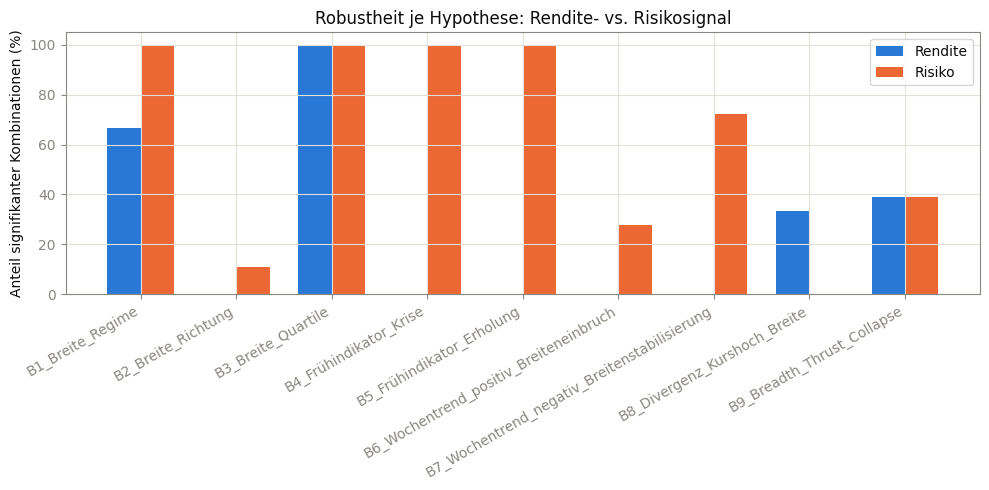

In [28]:
fig, achse = plt.subplots(figsize=(10, 5))
x = np.arange(len(pivot_robustheit))
breite = 0.35
achse.bar(x - breite / 2, pivot_robustheit["Anteil signifikant (Rendite)"] * 100, breite, label="Rendite", color=COLOR_A)
achse.bar(x + breite / 2, pivot_robustheit["Anteil signifikant (Risiko)"] * 100, breite, label="Risiko", color=COLOR_B)
achse.set_xticks(x)
achse.set_xticklabels(pivot_robustheit.index, rotation=30, ha="right")
achse.set_ylabel("Anteil signifikanter Kombinationen (%)")
achse.legend()
plt.title("Robustheit je Hypothese: Rendite- vs. Risikosignal")
plt.tight_layout()
plt.show()


**Ergebnis:** Anteil signifikanter Kombinationen (Risiko / Rendite) je
Hypothese: B1 100 %/67 %, B2 11 %/0 %, B3 100 %/100 %, B4 100 %/0 %, B5
100 %/0 %, B6 28 %/0 %, B7 72 %/0 %, B8 0 %/33 %, B9 39 %/39 %. Bei sieben
der neun Hypothesen (B1, B3, B4, B5, B6, B7 sowie ansatzweise B9) ist das
Risikosignal häufiger oder mindestens gleich häufig signifikant wie das
Renditesignal - die Marktbreite ist damit insgesamt ein deutlich robusteres
Risiko- als Renditesignal. Zwei Ausnahmen: B2 (Richtung der Breite) liefert insgesamt nur
ein schwaches Signal auf beiden Achsen, und B8 (Divergenz Kurshoch/Breite)
ist ausschließlich bei der Rendite signifikant - dort allerdings in der dem
klassischen Warnsignal entgegengesetzten Richtung (siehe 4.9).


## 5. Einordnung und Handlungsempfehlungen


Die neun Hypothesen zeigen insgesamt ein konsistentes Bild: Technische
Signale auf Basis der Marktbreite sagen deutlich mehr über das Risiko als
über die Rendite der Folgeperiode aus. In den *sequenziellen*
Ereignishypothesen (B4-B8), die allesamt als Warnsignal formuliert waren,
zeigt sich in den Daten des S&P 500 durchgehend entweder kein Effekt oder
ein dem Hypothesentext **entgegengesetzter** Effekt - insbesondere die als
Frühindikatoren formulierten B4 und B6 deuten eher auf gesunde
Verschnaufpausen als auf bevorstehende Risikophasen hin, während B5, B7 und
B9 (Collapse) auf anhaltend erhöhte Volatilität in ohnehin schon turbulenten
Phasen hindeuten, nicht auf ein eigenständiges Frühwarnsignal. Die
*zustandsbasierten* Hypothesen B1 und B3 (Marktbreite-Niveau) bleiben
dagegen die robustesten und am klarsten interpretierbaren Bausteine.

**Praxisrelevanz:** Für ein Ampelsystem eignet sich die Marktbreite vor
allem als Niveau-Kennzahl (B1/B3), nicht als Trigger für punktuelle
Schwellenkreuzungen. Die in mehreren Hypothesen wiederkehrende
Mean-Reversion-Wirkung (schwache Breite bzw. unbestätigte Hochs -> im
Mittel höhere Folgerendite) deutet darauf hin, dass kurzfristige
Breitensignale eher gegenläufig als bestätigend zu interpretieren sind.


## 6. Ampel-Systematik auf Basis der Marktbreite


### 6.1 Bausteine: Breiten-Trend-Score (B1 + B2) und Drawdown-Stufe

Ein **Breiten-Trend-Score** wird aus B1 (Marktbreite-Regime) und B2
(Richtung der Marktbreite) auf dem langfristigen SMA200-Fenster gebildet
und mit einer **Drawdown-Stufe** (Abstand des Index vom bisherigen Hoch)
kombiniert. Die Kombination aus Trend- und Risikoachse soll zeigen, ob die
Marktbreite als eigenständiger Baustein einer Ampel-Systematik einen
Mehrwert liefert.


In [29]:
def trend_score(zustand_gut: pd.Series, zustand_steigend: pd.Series) -> pd.Series:
    # 0 = beide Bedingungen günstig, 2 = beide ungünstig, 1 = gemischt.
    valide = zustand_gut.notna() & zustand_steigend.notna()
    score = pd.Series(np.nan, index=df.index)
    score[valide & zustand_gut & zustand_steigend] = 0
    score[valide & (zustand_gut != zustand_steigend)] = 1
    score[valide & ~zustand_gut & ~zustand_steigend] = 2
    return score


breite_sma200_über_50 = df["breite_sma200"] > 50
breite_sma200_steigend = df["breite_sma200"].diff() > 0
df["Breiten_Trend_Score"] = trend_score(breite_sma200_über_50, breite_sma200_steigend)

# Drawdown-Stufe (Abstand vom bisherigen Hoch), direkt aus dem Indexkurs
# berechnet.
df["Allzeithoch"] = df["Close"].cummax()
df["Abstand_vom_Hoch"] = df["Close"] / df["Allzeithoch"] - 1


def drawdown_bucket(x: float) -> str:
    if x >= -0.05:
        return "Nahe am Hoch (0 bis -5%)"
    elif x >= -0.10:
        return "Leichte Korrektur (-5 bis -10%)"
    elif x >= -0.20:
        return "Korrektur (-10 bis -20%)"
    else:
        return "Bärenmarkt (< -20%)"


df["Drawdown_Bucket"] = df["Abstand_vom_Hoch"].apply(drawdown_bucket)
bucket_reihenfolge = ["Nahe am Hoch (0 bis -5%)", "Leichte Korrektur (-5 bis -10%)",
                      "Korrektur (-10 bis -20%)", "Bärenmarkt (< -20%)"]

print("Verteilung des Breiten-Trend-Score (0 = günstig, 2 = ungünstig):")
print(df["Breiten_Trend_Score"].value_counts().sort_index())


Verteilung des Breiten-Trend-Score (0 = günstig, 2 = ungünstig):
Breiten_Trend_Score
0.0000    1831
1.0000    2424
2.0000     672
Name: count, dtype: int64


### 6.2 Empirische Grundlage der Kategoriengrenzen


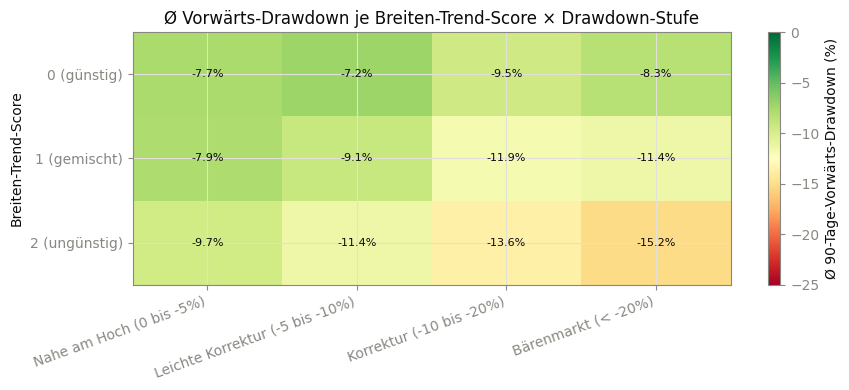

Drawdown_Bucket,Nahe am Hoch (0 bis -5%),Leichte Korrektur (-5 bis -10%),Korrektur (-10 bis -20%),Bärenmarkt (< -20%)
Breiten_Trend_Score,,,,
0.0000,-0.0774,-0.0718,-0.0951,-0.0833
1.0000,-0.0793,-0.0913,-0.1187,-0.1136
2.0000,-0.0967,-0.1140,-0.1364,-0.1515


In [30]:
heatmap_basis = df.groupby(["Breiten_Trend_Score", "Drawdown_Bucket"])["fwd_mdd_90d"].mean().unstack()
heatmap_basis = heatmap_basis[bucket_reihenfolge]

fig, achse = plt.subplots(figsize=(9, 4))
bild = achse.imshow(heatmap_basis.values * 100, cmap="RdYlGn", aspect="auto", vmin=-25, vmax=0)
achse.set_xticks(range(len(bucket_reihenfolge)))
achse.set_xticklabels(bucket_reihenfolge, rotation=20, ha="right")
achse.set_yticks(range(3))
achse.set_yticklabels(["0 (günstig)", "1 (gemischt)", "2 (ungünstig)"])
achse.set_ylabel("Breiten-Trend-Score")
for i in range(heatmap_basis.shape[0]):
    for j in range(heatmap_basis.shape[1]):
        wert = heatmap_basis.values[i, j]
        if not np.isnan(wert):
            achse.text(j, i, f"{wert * 100:.1f}%", ha="center", va="center", fontsize=8)
fig.colorbar(bild, ax=achse, label="Ø 90-Tage-Vorwärts-Drawdown (%)")
plt.title("Ø Vorwärts-Drawdown je Breiten-Trend-Score × Drawdown-Stufe")
plt.tight_layout()
plt.show()
heatmap_basis


### 6.3 Kategorienregel


In [31]:
def ampel_farbe(trend_score: float, drawdown_bucket: str) -> str:
    günstig = trend_score == 0
    ungünstig = trend_score == 2
    tief = drawdown_bucket in ("Korrektur (-10 bis -20%)", "Bärenmarkt (< -20%)")
    flach = drawdown_bucket in ("Nahe am Hoch (0 bis -5%)", "Leichte Korrektur (-5 bis -10%)")

    if günstig and flach:
        return "Grün"
    if ungünstig and tief:
        return "Rot"
    return "Gelb"


df["Ampel"] = [
    ampel_farbe(ts, db) if pd.notna(ts) else np.nan
    for ts, db in zip(df["Breiten_Trend_Score"], df["Drawdown_Bucket"])
]

print("Verteilung der Handelstage auf die drei Ampelfarben:")
print(df["Ampel"].value_counts().reindex(["Grün", "Gelb", "Rot"]))


Verteilung der Handelstage auf die drei Ampelfarben:
Ampel
Grün    1450
Gelb    3021
Rot      456
Name: count, dtype: int64


### 6.4 Statistische Validierung der Ampelfarben


In [32]:
ampel_farben = ["Grün", "Gelb", "Rot"]
ampel_paare = [("Grün", "Gelb"), ("Gelb", "Rot"), ("Grün", "Rot")]

ergebnisse_ampel = []
for a, b in ampel_paare:
    maske_a = df["Ampel"] == a
    maske_b = df["Ampel"] == b
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[maske_a, f"{ziel}_{h}d"], df.loc[maske_b, f"{ziel}_{h}d"],
                label_a=a, label_b=b,
            )
            if res:
                res.update({"vergleich": f"{a} vs. {b}", "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_ampel.append(res)

tabelle_ampel = ergebnisse_zu_tabelle(ergebnisse_ampel)
tabelle_ampel[["vergleich", "horizont_tage", "zielgröße", "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]]


,vergleich,horizont_tage,zielgröße,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,Grün vs. Gelb,30,fwd_return,0.0097,0.0115,0.2409,0.0022,False
1,Grün vs. Gelb,30,fwd_mdd,-0.0398,-0.0516,0.0000,0.0000,True
2,Grün vs. Gelb,60,fwd_return,0.0220,0.0230,0.6181,0.0249,False
3,Grün vs. Gelb,60,fwd_mdd,-0.0604,-0.0763,0.0000,0.0000,True
4,Grün vs. Gelb,90,fwd_return,0.0346,0.0354,0.7199,0.1156,False
5,Grün vs. Gelb,90,fwd_mdd,-0.0767,-0.0938,0.0000,0.0000,True
6,Gelb vs. Rot,30,fwd_return,0.0115,0.0210,0.0262,0.0000,True
7,Gelb vs. Rot,30,fwd_mdd,-0.0516,-0.0850,0.0000,0.0000,True
8,Gelb vs. Rot,60,fwd_return,0.0230,0.0334,0.0826,0.0000,False
9,Gelb vs. Rot,60,fwd_mdd,-0.0763,-0.1186,0.0000,0.0000,True


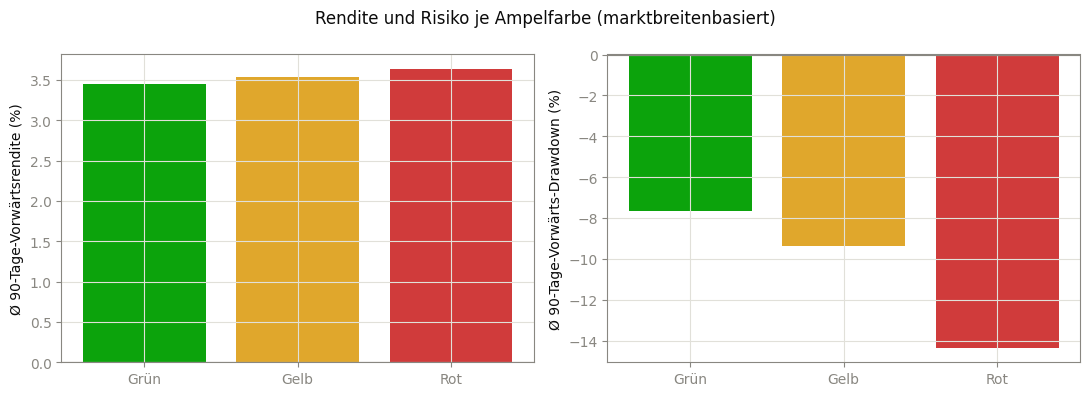

In [33]:
mittelwerte_ampel = df.groupby("Ampel")[["fwd_return_90d", "fwd_mdd_90d"]].mean().reindex(ampel_farben)
ampel_farbcodes = {"Grün": COLOR_GOOD, "Gelb": COLOR_WARN, "Rot": COLOR_BAD}

fig, achsen = plt.subplots(1, 2, figsize=(11, 4))
for achse, spalte, titel in zip(achsen, ["fwd_return_90d", "fwd_mdd_90d"],
                                 ["Ø 90-Tage-Vorwärtsrendite", "Ø 90-Tage-Vorwärts-Drawdown"]):
    achse.bar(mittelwerte_ampel.index, mittelwerte_ampel[spalte] * 100,
              color=[ampel_farbcodes[f] for f in mittelwerte_ampel.index])
    achse.axhline(0, color=COLOR_MUTED, linewidth=0.8)
    achse.set_ylabel(f"{titel} (%)")
fig.suptitle("Rendite und Risiko je Ampelfarbe (marktbreitenbasiert)")
fig.tight_layout()
plt.show()


**Ergebnis:** Verteilung der Handelstage: Grün 1.450 (29,4 %), Gelb 3.021
(61,3 %), Rot 456 (9,3 %). Das Risiko trennt alle drei Farbpaare in allen
drei Horizonten signifikant und monoton (mittlerer 90-Tage-Drawdown: Grün
-7,7 %, Gelb -9,4 %, Rot -14,3 %). Die Rendite ist dagegen kaum
differenzierend: Zwischen Grün und Gelb ist der Unterschied in keinem
Horizont signifikant, zwischen Gelb/Rot bzw. Grün/Rot nur beim
kurzfristigsten Horizont (30 Tage); bei 90 Tagen liegen alle drei Farben
mit 3,5-3,6 % mittlerer Vorwärtsrendite praktisch gleichauf. Die
marktbreitenbasierte Ampel funktioniert damit in erster Linie als
Risikostufung, nicht als Renditeprognose.


### 6.5 Ampel-Hintergrund im Kursverlauf


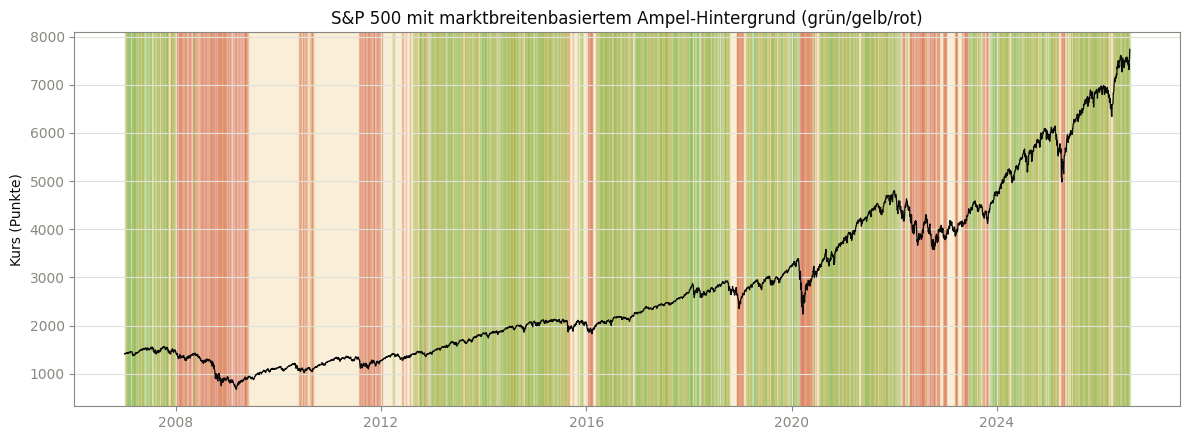

In [34]:
fig, achse = plt.subplots(figsize=(12, 4.5))
for farbe in ampel_farben:
    maske = df["Ampel"] == farbe
    achse.fill_between(df.index, 0, 1, where=maske, color=ampel_farbcodes[farbe], alpha=0.18,
                        transform=achse.get_xaxis_transform())
achse.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse.set_ylabel("Kurs (Punkte)")
achse.set_title(f"{INDEX_NAME} mit marktbreitenbasiertem Ampel-Hintergrund (grün/gelb/rot)")
fig.tight_layout()
plt.show()


## 7. Was-wäre-wenn-Analyse: Wirkung des Risikophasen-Ausschlusses

Für jede Hypothese, bei der sich ein **anhaltender** Regimezustand
definieren lässt (im Unterschied zu den punktuellen Ereignishypothesen
B4-B9), wird simuliert, wie sich Gesamtrendite, annualisierte Rendite (CAGR)
und maximaler Drawdown verändert hätten, wenn an Tagen mit dem jeweils
ungünstigeren Regimezustand nicht investiert gewesen wäre.

**Methodische Abgrenzung:** Es wird ausschließlich der zum jeweiligen
Zeitpunkt bereits bekannte Regimezustand verwendet (kein Rückschaufehler).
Transaktionskosten und eine Verzinsung der Cash-Position an ausgeschlossenen
Tagen werden nicht berücksichtigt.

**B4, B5, B6, B7, B8 und B9 werden bewusst ausgeschlossen:** Es handelt sich
um seltene Punktereignisse bzw. Divergenzsignale ohne anhaltenden
Regimezustand - daraus lässt sich keine Phase ableiten, die über einen
längeren Zeitraum "ausgeschlossen" werden könnte. Einbezogen werden B1
(Marktbreite-Regime), B2 (Richtung der Marktbreite), B3 (unteres Quartil als
Risikostufe) sowie die kombinierte Ampel aus Abschnitt 6.


### 7.1 Backtest-Hilfsfunktionen


In [35]:
def historischer_max_drawdown(werte: pd.Series) -> float:
    laufendes_hoch = werte.cummax()
    return (werte / laufendes_hoch - 1).min()


def was_wäre_wenn(schlecht: pd.Series, label: str) -> dict:
    tagesrendite = df["Close"].pct_change().fillna(0)
    schlecht_bereinigt = schlecht.reindex(df.index).fillna(False)

    strategie_rendite = tagesrendite.where(~schlecht_bereinigt, 0)
    equity_buy_hold = (1 + tagesrendite).cumprod()
    equity_strategie = (1 + strategie_rendite).cumprod()

    jahre = (df.index[-1] - df.index[0]).days / 365.25

    def kennzahlen(equity: pd.Series) -> tuple[float, float, float]:
        gesamtrendite = equity.iloc[-1] - 1
        cagr = equity.iloc[-1] ** (1 / jahre) - 1
        mdd = historischer_max_drawdown(equity)
        return gesamtrendite, cagr, mdd

    gr_bh, cagr_bh, mdd_bh = kennzahlen(equity_buy_hold)
    gr_st, cagr_st, mdd_st = kennzahlen(equity_strategie)

    return {
        "hypothese": label,
        "anteil_schlecht_tage": schlecht_bereinigt.mean(),
        "gesamtrendite_buy_hold": gr_bh, "cagr_buy_hold": cagr_bh, "max_drawdown_buy_hold": mdd_bh,
        "gesamtrendite_strategie": gr_st, "cagr_strategie": cagr_st, "max_drawdown_strategie": mdd_st,
        "equity_buy_hold": equity_buy_hold, "equity_strategie": equity_strategie,
    }


print("Backtest-Hilfsfunktionen definiert.")


Backtest-Hilfsfunktionen definiert.


### 7.2 Regime-Definitionen je Hypothese


In [36]:
regime_definitionen: dict[str, pd.Series] = {}

for w in BREADTH_WINDOWS:
    über, _ = breite_regime(w)
    regime_definitionen[f"B1_SMA{w}"] = ~über.reindex(df.index).fillna(False)

for w in BREADTH_WINDOWS:
    steigend, _ = breite_richtung(w)
    regime_definitionen[f"B2_SMA{w}"] = ~steigend.reindex(df.index).fillna(False)

for w in BREADTH_WINDOWS:
    regime_definitionen[f"B3_SMA{w}_Q1"] = df[f"Quartil_SMA{w}"] == QUARTIL_LABELS[0]

regime_definitionen["Ampel_Rot"] = df["Ampel"] == "Rot"

# Um einen Rückschaufehler zu vermeiden, darf am Handelstag T nur der am
# Schlusskurs von T-1 bereits bekannte Regimezustand über die Teilnahme an
# Tag T entscheiden - nicht der auf Basis von T selbst berechnete Zustand.
regime_definitionen = {
    name: serie.reindex(df.index).fillna(False).shift(1).fillna(False).astype(bool)
    for name, serie in regime_definitionen.items()
}

print("Regime-Definitionen für die Was-wäre-wenn-Analyse:", list(regime_definitionen.keys()))


Regime-Definitionen für die Was-wäre-wenn-Analyse: ['B1_SMA20', 'B1_SMA50', 'B1_SMA200', 'B2_SMA20', 'B2_SMA50', 'B2_SMA200', 'B3_SMA20_Q1', 'B3_SMA50_Q1', 'B3_SMA200_Q1', 'Ampel_Rot']


### 7.3 Konsolidierte Kennzahlenübersicht


In [37]:
ergebnisse_www = [was_wäre_wenn(schlecht, name) for name, schlecht in regime_definitionen.items()]
tabelle_was_wäre_wenn = pd.DataFrame(ergebnisse_www).drop(columns=["equity_buy_hold", "equity_strategie"])
tabelle_was_wäre_wenn


,hypothese,anteil_schlecht_tage,gesamtrendite_buy_hold,cagr_buy_hold,max_drawdown_buy_hold,gesamtrendite_strategie,cagr_strategie,max_drawdown_strategie
0,B1_SMA20,0.3678,4.4613,0.0906,-0.5678,0.8770,0.0327,-0.3740
1,B1_SMA50,0.3320,4.4613,0.0906,-0.5678,0.7816,0.0299,-0.4327
2,B1_SMA200,0.2561,4.4613,0.0906,-0.5678,2.2378,0.0618,-0.2466
3,B2_SMA20,0.5076,4.4613,0.0906,-0.5678,-0.1656,-0.0092,-0.6568
4,B2_SMA50,0.4995,4.4613,0.0906,-0.5678,-0.0771,-0.0041,-0.6436
5,B2_SMA200,0.5086,4.4613,0.0906,-0.5678,-0.2876,-0.0172,-0.5537
6,B3_SMA20_Q1,0.1295,4.4613,0.0906,-0.5678,1.4601,0.0470,-0.5646
7,B3_SMA50_Q1,0.0986,4.4613,0.0906,-0.5678,1.9630,0.0570,-0.5499
8,B3_SMA200_Q1,0.0698,4.4613,0.0906,-0.5678,2.4172,0.0648,-0.3846
9,Ampel_Rot,0.0926,4.4613,0.0906,-0.5678,0.9514,0.0347,-0.4921


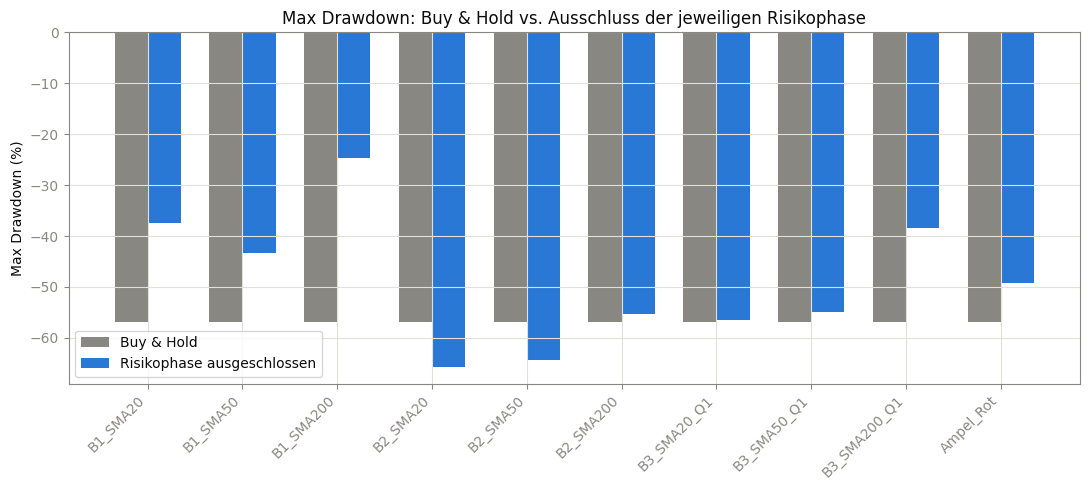

In [38]:
fig, achse = plt.subplots(figsize=(11, 5))
x = np.arange(len(tabelle_was_wäre_wenn))
breite = 0.35
achse.bar(x - breite / 2, tabelle_was_wäre_wenn["max_drawdown_buy_hold"] * 100, breite,
          label="Buy & Hold", color=COLOR_MUTED)
achse.bar(x + breite / 2, tabelle_was_wäre_wenn["max_drawdown_strategie"] * 100, breite,
          label="Risikophase ausgeschlossen", color=COLOR_A)
achse.set_xticks(x)
achse.set_xticklabels(tabelle_was_wäre_wenn["hypothese"], rotation=45, ha="right")
achse.set_ylabel("Max Drawdown (%)")
achse.legend()
plt.title("Max Drawdown: Buy & Hold vs. Ausschluss der jeweiligen Risikophase")
plt.tight_layout()
plt.show()


**Ergebnis:** Buy & Hold erzielt seit 2007 eine Gesamtrendite von 446 %
(CAGR 9,1 %) bei einem Max Drawdown von -56,8 %. Der Ausschluss der
jeweils „schlechten“ Marktbreite-Regime senkt den Max Drawdown nicht in
allen zehn Parametrisierungen: Am stärksten wirkt B1/SMA200 (25,6 %
ausgeschlossene Tage), das den Max Drawdown auf -24,7 % senkt, bei einer
gegenüber Buy & Hold moderat geringeren CAGR von 6,2 %. Auch B3/SMA200_Q1
(7,0 % ausgeschlossene Tage, Max Drawdown -38,5 %, CAGR 6,5 %) und die
kombinierte Ampel (9,3 % ausgeschlossene Tage, Max Drawdown -49,2 %, CAGR
3,5 %) reduzieren das Risiko spürbar, jeweils auf Kosten eines Teils der
Rendite. Bei B2 (Richtung der Marktbreite, 50-51 % ausgeschlossene Tage je
Fenster) kehrt sich der erhoffte Effekt sogar um: Der Max Drawdown
verschlechtert sich gegenüber Buy & Hold (-64,4 % bis -65,7 % statt
-56,8 %) bei gleichzeitig negativer CAGR (-0,4 % bis -1,7 %) - das damit
verbundene, sehr häufige Wechseln des Signals (rund jeden zweiten
Handelstag) liefert kein handelbares Risikosignal.


### 7.4 Vertiefte Einzelbetrachtung

Für die kombinierte Ampel (Rot-Phasen) wird zusätzlich der zeitliche
Verlauf dargestellt: oben der Kursverlauf mit rot hinterlegter
Ausschlussphase, darunter die Wertentwicklung von Buy & Hold gegenüber der
Ausschluss-Strategie (logarithmische Skala, Startwert = 1).


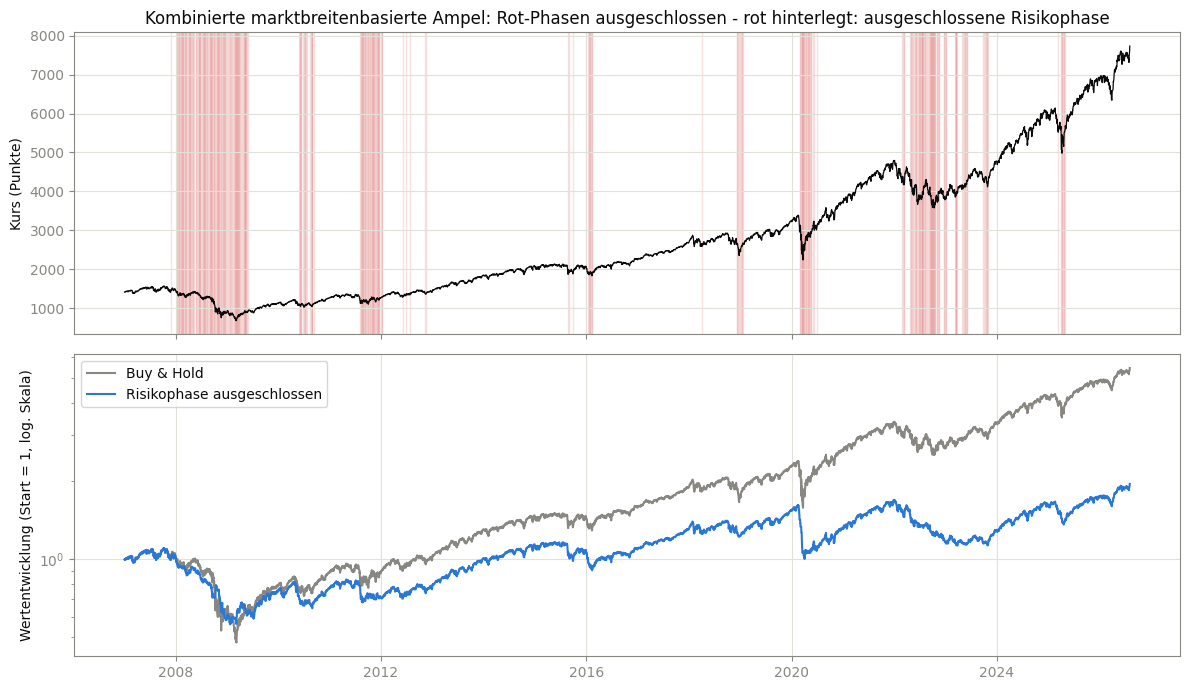

Anteil ausgeschlossener Handelstage: 9.3%
Gesamtrendite  - Buy & Hold: 446.1% | Ausschluss: 95.1%
CAGR           - Buy & Hold: 9.1% | Ausschluss: 3.5%
Max Drawdown   - Buy & Hold: -56.8% | Ausschluss: -49.2%


In [39]:
def plotte_was_wäre_wenn(name: str, schlecht: pd.Series, titel: str) -> dict:
    ergebnis = was_wäre_wenn(schlecht, name)
    schlecht_reindiziert = schlecht.reindex(df.index).fillna(False)

    fig, (achse_kurs, achse_equity) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    achse_kurs.fill_between(df.index, 0, 1, where=schlecht_reindiziert, color=COLOR_BAD, alpha=0.15,
                             transform=achse_kurs.get_xaxis_transform())
    achse_kurs.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
    achse_kurs.set_ylabel("Kurs (Punkte)")
    achse_kurs.set_title(f"{titel} - rot hinterlegt: ausgeschlossene Risikophase")

    achse_equity.plot(df.index, ergebnis["equity_buy_hold"], color=COLOR_MUTED, label="Buy & Hold")
    achse_equity.plot(df.index, ergebnis["equity_strategie"], color=COLOR_A, label="Risikophase ausgeschlossen")
    achse_equity.set_yscale("log")
    achse_equity.set_ylabel("Wertentwicklung (Start = 1, log. Skala)")
    achse_equity.legend()

    fig.tight_layout()
    plt.show()

    print(f"Anteil ausgeschlossener Handelstage: {ergebnis['anteil_schlecht_tage']:.1%}")
    print(f"Gesamtrendite  - Buy & Hold: {ergebnis['gesamtrendite_buy_hold']:.1%} | Ausschluss: {ergebnis['gesamtrendite_strategie']:.1%}")
    print(f"CAGR           - Buy & Hold: {ergebnis['cagr_buy_hold']:.1%} | Ausschluss: {ergebnis['cagr_strategie']:.1%}")
    print(f"Max Drawdown   - Buy & Hold: {ergebnis['max_drawdown_buy_hold']:.1%} | Ausschluss: {ergebnis['max_drawdown_strategie']:.1%}")
    return ergebnis


_ = plotte_was_wäre_wenn("Ampel_Rot", regime_definitionen["Ampel_Rot"], "Kombinierte marktbreitenbasierte Ampel: Rot-Phasen ausgeschlossen")


**Ergebnis:** Der Ausschluss der 9,3 % Rot-Handelstage senkt den Max
Drawdown von -56,8 % (Buy & Hold) auf -49,2 % und senkt zugleich die
annualisierte Rendite von 9,1 % auf 3,5 %. Der Risikophasen-Ausschluss ist
damit kein „Free Lunch“, sondern ein Trade-off zwischen Risiko und
Rendite, der hier deutlich zulasten der Rendite ausfällt. Der Kursverlauf
zeigt, dass die Rot-Phasen erwartungsgemäß mit den großen historischen
Krisenphasen (2008/2009, 2020, 2022) zusammenfallen.


## 8. Export der Ergebnisse


In [40]:
INDEX_DATEINAME = INDEX_NAME.replace(" ", "_").replace("&", "and")

xlsx_pfad = EXPORT_DIR / f"{INDEX_DATEINAME}_Marktbreite_hypothesenanalysen.xlsx"
with pd.ExcelWriter(xlsx_pfad, engine="openpyxl") as writer:
    for name, tabelle in alle_ergebnisse.items():
        if tabelle is not None and len(tabelle) > 0:
            tabelle.to_excel(writer, sheet_name=name[:31], index=False)
    tabelle_robustheit.to_excel(writer, sheet_name="Robustheit_Übersicht", index=False)
    tabelle_ampel.to_excel(writer, sheet_name="Ampel_Validierung", index=False)
    tabelle_was_wäre_wenn.to_excel(writer, sheet_name="Was_wäre_wenn", index=False)

csv_dateien = []
for name, tabelle in alle_ergebnisse.items():
    if tabelle is None or len(tabelle) == 0:
        continue
    csv_pfad = EXPORT_DIR / f"{INDEX_DATEINAME}_{name}.csv"
    tabelle.to_csv(csv_pfad, index=False)
    csv_dateien.append(csv_pfad.name)

robustheit_csv = EXPORT_DIR / f"{INDEX_DATEINAME}_Robustheit_Übersicht.csv"
tabelle_robustheit.to_csv(robustheit_csv, index=False)
csv_dateien.append(robustheit_csv.name)

ampel_csv = EXPORT_DIR / f"{INDEX_DATEINAME}_Ampel_Validierung.csv"
tabelle_ampel.to_csv(ampel_csv, index=False)
csv_dateien.append(ampel_csv.name)

was_wäre_wenn_csv = EXPORT_DIR / f"{INDEX_DATEINAME}_Was_wäre_wenn.csv"
tabelle_was_wäre_wenn.to_csv(was_wäre_wenn_csv, index=False)
csv_dateien.append(was_wäre_wenn_csv.name)

print(f"Excel-Arbeitsmappe gespeichert: {xlsx_pfad}")
print("Einzel-CSV-Dateien gespeichert:")
for f in csv_dateien:
    print(" -", f)


Excel-Arbeitsmappe gespeichert: Hypothesenanalysen\SandP_500_Marktbreite_hypothesenanalysen.xlsx
Einzel-CSV-Dateien gespeichert:
 - SandP_500_B1_Breite_Regime.csv
 - SandP_500_B2_Breite_Richtung.csv
 - SandP_500_B3_Breite_Quartile.csv
 - SandP_500_B4_Frühindikator_Krise.csv
 - SandP_500_B5_Frühindikator_Erholung.csv
 - SandP_500_B6_Wochentrend_positiv_Breiteneinbruch.csv
 - SandP_500_B7_Wochentrend_negativ_Breitenstabilisierung.csv
 - SandP_500_B8_Divergenz_Kurshoch_Breite.csv
 - SandP_500_B9_Breadth_Thrust_Collapse.csv
 - SandP_500_Robustheit_Übersicht.csv
 - SandP_500_Ampel_Validierung.csv
 - SandP_500_Was_wäre_wenn.csv


## 9. Zusammenfassung


Dieses Notebook untersucht, ob die Marktbreite des S&P 500 (Anteil der
Indexmitglieder über ihrem eigenen SMA20/50/200) eine eigenständige,
statistisch prüfbare Aussagekraft für die Rendite- und Risikoentwicklung
des Gesamtindex besitzt. Datengrundlage sind tägliche TradingView-
Breitendaten (2007-2026) sowie bereits bereinigte Kurs- und SMA-Daten des
Index.

**Kernbefunde:**

- Das *Niveau* der Marktbreite (B1: Regime > 50 %/< 50 %; B3: Quartile)
  liefert die robustesten Signale: Risiko durchgehend signifikant (18/18
  Kombinationen), Rendite teilweise (B1: 6/9) bis vollständig (B3:
  9/9) signifikant.
- Die *Richtung* der Marktbreite (B2) liefert dagegen kaum eigenständige
  Information (1 von 18 signifikant).
- Alle fünf sequenziellen Frühindikator-Hypothesen (B4-B8) zeigen
  entweder keinen oder einen dem Hypothesentext **entgegengesetzten**
  Effekt: B4 und B6 (Warnsignale bei positivem Trend) gehen mit
  **geringerem**, nicht höherem Risiko einher; B5 und B7 (Signale bei
  negativem Trend) mit **höherem** Risiko statt einer "ruhigen Erholung";
  B8 zeigt bei unbestätigten Hochs **höhere**, nicht niedrigere Rendite.
- B9 (Breadth Collapse) ist die einzige Ereignishypothese mit robustem
  Effekt auf beiden Achsen gleichzeitig: höhere Rendite **und** höheres
  Risiko - ein klassisches Risiko-Rendite- statt Warnmuster.
- Die marktbreitenbasierte Ampel (Kapitel 6) trennt das Risiko klar und
  monoton (Grün -7,7 %, Gelb -9,4 %, Rot -14,3 % mittlerer
  90-Tage-Drawdown), die Rendite kaum. Der Ausschluss der Rot-Phasen
  (9,3 % der Handelstage) senkt den historischen Max Drawdown von -56,8 %
  auf -49,2 %, geht aber mit einem deutlichen Rückgang der CAGR von 9,1 %
  auf 3,5 % einher (Kapitel 7).

**Übergreifende Einordnung:** Technische Signale auf Basis der Marktbreite
taugen in den Daten des S&P 500 zuverlässiger als Risikoindikator denn als
Renditeprognose. Für punktuelle Schwellenkreuzungen (B4-B8) zeigt sich
zudem durchgängig eine Mean-Reversion-Tendenz statt einer Bestätigung der
jeweils formulierten Warnhypothese.
